In [ ]:
# Enable autoreload so helper edits refresh automatically.
%load_ext autoreload
%autoreload 2
%pip install -e ./metanet-calibration

from pathlib import Path
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
warnings.filterwarnings("ignore")

from pems.pems_utils import (
    increase_resolution,
    plot_matrix,
    process_pems,
    summarize_sparsity,
    get_ramps_per_segment,
    get_lanes_per_segment,
    run_asmx
)

plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.titlesize": 13,
    "figure.facecolor": "white",
})

# Edit this section for a new corridor / experiment.
CONFIG = {
    "paths": {
        "inputs_dir": "data/I5_S_pm_115_to_95",
        "outputs_dir": "outputs/I5_S_pm_115_to_109_7_to_8",
        "ramps_filename": "ramps_validated.csv",
        "lanes_filename": "lanes_validated.csv",
        "stations_filename": "district12_stations.txt",
        "traffic_data_filename": "district12_011426_data.txt",
        "output_arrays_subdir": "arrays",
        "output_figures_subdir": "figures"
    },
    "corridor": {
        "freeway_id": 5,
        "direction": "S",
        "start_abs_pm": 115,
        "end_abs_pm": 109,
        "min_hour": 7,
        "max_hour": 8,
    },
    "grid": {
        "space_step_km": 0.4,
        "time_step_seconds": 30,
    }
}

# Resolve input/output locations.
input_dir = Path(CONFIG["paths"]["inputs_dir"])
array_dir = Path(CONFIG["paths"]["outputs_dir"]) / CONFIG["paths"]["output_arrays_subdir"]
figure_dir = Path(CONFIG["paths"]["outputs_dir"]) / CONFIG["paths"]["output_figures_subdir"]

# create output directories.
for output_dir in [array_dir, figure_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)

# Derived file paths.
MILES_TO_KM = 1.60934
ramps_path = input_dir / CONFIG["paths"]["ramps_filename"]
lanes_path = input_dir / CONFIG["paths"]["lanes_filename"]
station_data_path = input_dir / CONFIG["paths"]["stations_filename"]
detector_data_path = input_dir / CONFIG["paths"]["traffic_data_filename"]

fwy_station_identifier = CONFIG["corridor"]["freeway_id"]
fwy_direction = CONFIG["corridor"]["direction"]
START_ABS_PM = CONFIG["corridor"]["start_abs_pm"]
END_ABS_PM = CONFIG["corridor"]["end_abs_pm"]
MIN_HOUR = CONFIG["corridor"]["min_hour"]
MAX_HOUR = CONFIG["corridor"]["max_hour"]

SPACE_STEP_KM = CONFIG["grid"]["space_step_km"]
SPACE_STEP_MI = SPACE_STEP_KM / MILES_TO_KM
TIME_INCREMENT_SECONDS = pd.Timedelta(seconds=CONFIG["grid"]["time_step_seconds"])

CALIBRATION_CONFIG = CONFIG["calibration"]

print("Active corridor configuration:")
print(f"  Freeway {fwy_station_identifier} {fwy_direction}")
print(f"  PM window: {START_ABS_PM} -> {END_ABS_PM}")
print(f"  Hour window: {MIN_HOUR}:00 to {MAX_HOUR}:00")
print(f"  Grid: {SPACE_STEP_KM} km x {TIME_INCREMENT_SECONDS}")
print(f"  Inputs: {input_dir}")
print(f"  Outputs: arrays={array_dir}, figures={figure_dir}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Obtaining file:///Users/andrewmiller/Desktop/LIDS/metanet_pipeline/metanet-calibration
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for metanet-calibration (pyproject.toml) ... done
  Created wheel for metanet-calibration: filename=metanet_calibration-0.1.1-0.editable-py3-none-any.whl size=2951 sha256=bbd34380491352c8b9d1f416919725afe9cd1ec1b1ef9e172415ce23a7d1f514
  Stored in directory: /private/var/folders/gf/_j_dmrsx1l7dldxn8zshjgbc0000gn/T/pip-ephem-wheel-cache-imtcyq6_/wheels/c3/ee/bf/b2ed8714e20bcae11fb3a9075222d292c73b01cdefa918c39d
Successfully built metanet-calibration
  Attempting uninstall: metanet-calibration
    Found existing installation: metanet-calibration 0.1.1
    Uninstalling metanet-calibration-0.1.

# 1. Data Preprocessing
### 1.1 Load and Process Detector Stations, Ramp Locations, and Lane Configurations

In [ ]:
# Station preprocessing:
# 1. filter the requested corridor,
# 2. infer direction of travel,
# 3. build per-bin ramp and lane mappings used downstream.

# Load station metadata
stations = pd.read_csv(station_data_path, sep="\t")
rename_map = {col: col.lower().replace(" ", "_") for col in stations.columns}
stations.rename(columns=rename_map, inplace=True)
stations.rename(columns={"id": "station_id"}, inplace=True)

# Infer the direction of the postmile progression
postmile_dxn = 1 if END_ABS_PM > START_ABS_PM else -1

# Filter to correct fwy and direction mainline/HOV stations within the desired postmile window.
stations = stations[(stations["fwy"] == fwy_station_identifier) & (stations["dir"] == fwy_direction)]
# stations = stations[stations["type"].isin(["ML", "HV"])]
stations = stations[stations['type'].isin(["ML", "HV", "OR", "FR", "FF", "CD"])]
min_pm = min(START_ABS_PM, END_ABS_PM)
max_pm = max(START_ABS_PM, END_ABS_PM)
stations = stations[(stations["abs_pm"] > min_pm) & (stations["abs_pm"] < max_pm)]

# Quick sanity check on mainline detector spacing.
print("Summary of station lengths:\n", stations["length"].describe())

# Update the start and end postmiles to the precise postmile locations of the first and last stations
if postmile_dxn == 1:
    start_pm = stations["abs_pm"].min()
    end_pm = stations["abs_pm"].max()
else:
    start_pm = stations["abs_pm"].max()
    end_pm = stations["abs_pm"].min()

# Create a ramp/lane mapping
on_ramp, off_ramp, edges = get_ramps_per_segment(ramps_path, start_pm, end_pm, SPACE_STEP_MI)
lanes_per_bin = get_lanes_per_segment(lanes_path, start_pm, end_pm, SPACE_STEP_MI, debug=True)

np.save(array_dir / "on_ramp_map.npy", on_ramp)
np.save(array_dir / "off_ramp_map.npy", off_ramp)
np.save(array_dir / "lane_map.npy", lanes_per_bin)

# Sanity Checks
print('')
print("Number of Detected Space Bins:", len(on_ramp))
print("Range of Lanes per Bin:", lanes_per_bin.min(), "-", lanes_per_bin.max())
print('Verify Space Bin Edges:', edges)
print('')
print('Ramp Mapping:')
print('  On-Ramp:', on_ramp)
print('  Off-Ramp:', off_ramp)
print('Percent of Segments with a ramp:', np.sum((on_ramp + off_ramp) > 0) / len(on_ramp))

# save the space bin edges to a numpy file
np.save(array_dir / "space_bin_edges.npy", edges)

['ML' 'OR' 'FR' 'HV' 'FF' 'CD']
Summary of station lengths:
 count    31.000000
mean      0.390645
std       0.077575
min       0.245000
25%       0.355000
50%       0.410000
75%       0.445000
max       0.500000
Name: length, dtype: float64
Ramp bin 0 [114.63945090534008, 114.888): 0 on-ramps, 1 off-ramps
Ramp bin 1 [114.39090181068016, 114.63945090534008): 0 on-ramps, 1 off-ramps
Ramp bin 2 [114.14235271602024, 114.39090181068016): 0 on-ramps, 0 off-ramps
Ramp bin 3 [113.89380362136032, 114.14235271602024): 1 on-ramps, 0 off-ramps
Ramp bin 4 [113.6452545267004, 113.89380362136032): 1 on-ramps, 0 off-ramps
Ramp bin 5 [113.39670543204046, 113.6452545267004): 0 on-ramps, 0 off-ramps
Ramp bin 6 [113.14815633738054, 113.39670543204046): 0 on-ramps, 1 off-ramps
Ramp bin 7 [112.89960724272062, 113.14815633738054): 0 on-ramps, 0 off-ramps
Ramp bin 8 [112.6510581480607, 112.89960724272062): 0 on-ramps, 0 off-ramps
Ramp bin 9 [112.40250905340078, 112.6510581480607): 1 on-ramps, 0 off-ramps
Ram

### 1.2 Load and Clean Detector Demand Data


In [55]:
# Load mainline detector data (comma-separated text) and inspect the header.
demand = pd.read_csv(detector_data_path, sep=",")
demand.columns = (
    ["timestamp", "id"]
    + [
        f"lane {lane} {metric}"
        for lane in range(1, 9)
        for metric in ("flow", "occupancy", "speed")
    ]
)
rename_map = {col: col.lower().replace(" ", "_") for col in demand.columns}
demand.rename(columns=rename_map, inplace=True)
demand.rename(columns={"id": "station_id"}, inplace=True)

# Filter by hour window.
demand['timestamp'] = pd.to_datetime(demand['timestamp'])
demand = demand[
    (demand["timestamp"].dt.hour >= MIN_HOUR)
    & (demand["timestamp"].dt.hour < MAX_HOUR)
].copy()
# Round timestamps to 30-second bins.
demand["timestamp"] = demand["timestamp"].dt.floor("30S")

# For all columns containing the string 'lane', convert 0 values to nan
lane_cols = [col for col in demand.columns if "lane" in col.lower()]
demand[lane_cols] = demand[lane_cols].replace(0, np.nan)

### 1.3 Split Mainline and HOV Stations


In [56]:
print("Number of ML stations within range:", stations[stations["type"] == "ML"].shape[0])
print("Number of HOV stations within range:", stations[stations["type"] == "HV"].shape[0])
print("Number of On-Ramp stations within range:", stations[stations["type"] == "OR"].shape[0])
print("Number of Off-Ramp stations within range:", stations[stations["type"] == "FR"].shape[0])
print("Number of CD stations within range:", stations[stations["type"] == "CD"].shape[0])
print("Number of FF stations within range:", stations[stations["type"] == "FF"].shape[0])

# Join station postmile to df
demand = demand.merge(stations[["station_id", "abs_pm"]], on="station_id", how="left")

# Split mainline vs. HOV station info.
hov_stations = stations.loc[stations["type"] == "HV", ["station_id", "abs_pm", "length", "latitude", "longitude"]]
ml_stations = stations.loc[stations["type"] == "ML", ["station_id", "abs_pm", "length", "latitude", "longitude"]]

# Figure out which ML and HOV sensors share a station
ml_hov_shared = ml_stations[ml_stations["abs_pm"].isin(hov_stations["abs_pm"])]
print('')
print("Shared HOV and ML stations (by abs_pm):\n", ml_hov_shared)

# Figure out how many ML stations are standalone (no HOV readers)
ml_hov_unshared = ml_stations[~ml_stations["abs_pm"].isin(hov_stations["abs_pm"])]
print('')
print("Standalone ML stations (by abs_pm):\n", ml_hov_unshared)

# Figure out how many HOV stations are standalone (no ML readers)
hov_ml_unshared = hov_stations[~hov_stations["abs_pm"].isin(ml_stations["abs_pm"])]
print('')
print("Standalone HOV stations (by abs_pm):\n", hov_ml_unshared)

Number of ML stations within range: 115
Number of HOV stations within range: 105
Number of On-Ramp stations within range: 53
Number of Off-Ramp stations within range: 54
Number of CD stations within range: 4
Number of FF stations within range: 22

Shared HOV and ML stations (by abs_pm):
       station_id  abs_pm  length   latitude   longitude
681      1204273  75.755   0.435  33.440044 -117.624646
694      1204357  78.795   0.175  33.465471 -117.667379
704      1204415  81.595   0.475  33.499521 -117.658583
707      1204428  82.895   0.300  33.517588 -117.664664
710      1204442  83.565   0.455  33.526418 -117.668912
...          ...     ...     ...        ...         ...
2395     1221795  87.518   0.250  33.581647 -117.671917
2401     1221819  88.625   0.100  33.596833 -117.675263
2403     1221827  88.783   0.380  33.598386 -117.677370
2409     1221851  88.075   0.250  33.589674 -117.671796
2422     1222000  84.744   0.200  33.541593 -117.674195

[93 rows x 5 columns]

Standalone ML s

In [57]:
ramps = stations[(stations['type'] != 'HV') & (stations['type'] != 'ML')]
ramps.to_csv("ramp_detectors.csv")

### 1.4 Inspect Data Sparsity


Mainline Data ----------------------------------------------
Mainline Data sensor readings: 91,784


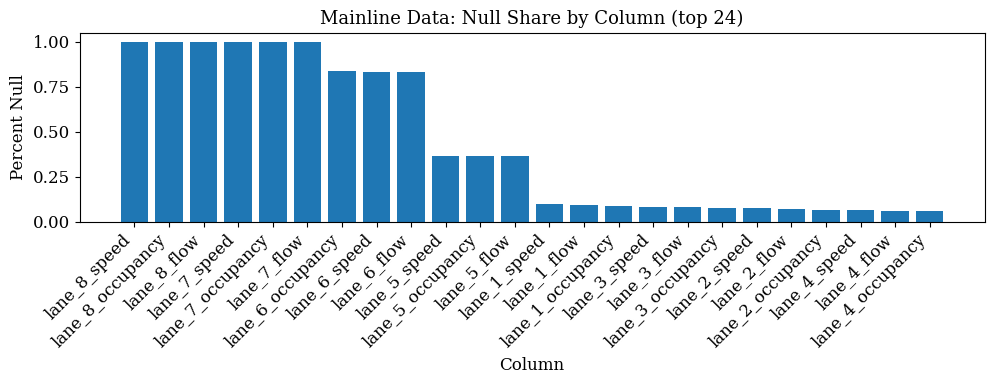

Dropping 6 fully sparse columns
Mainline Data null summary (by station_id):
Total rows: 91,784


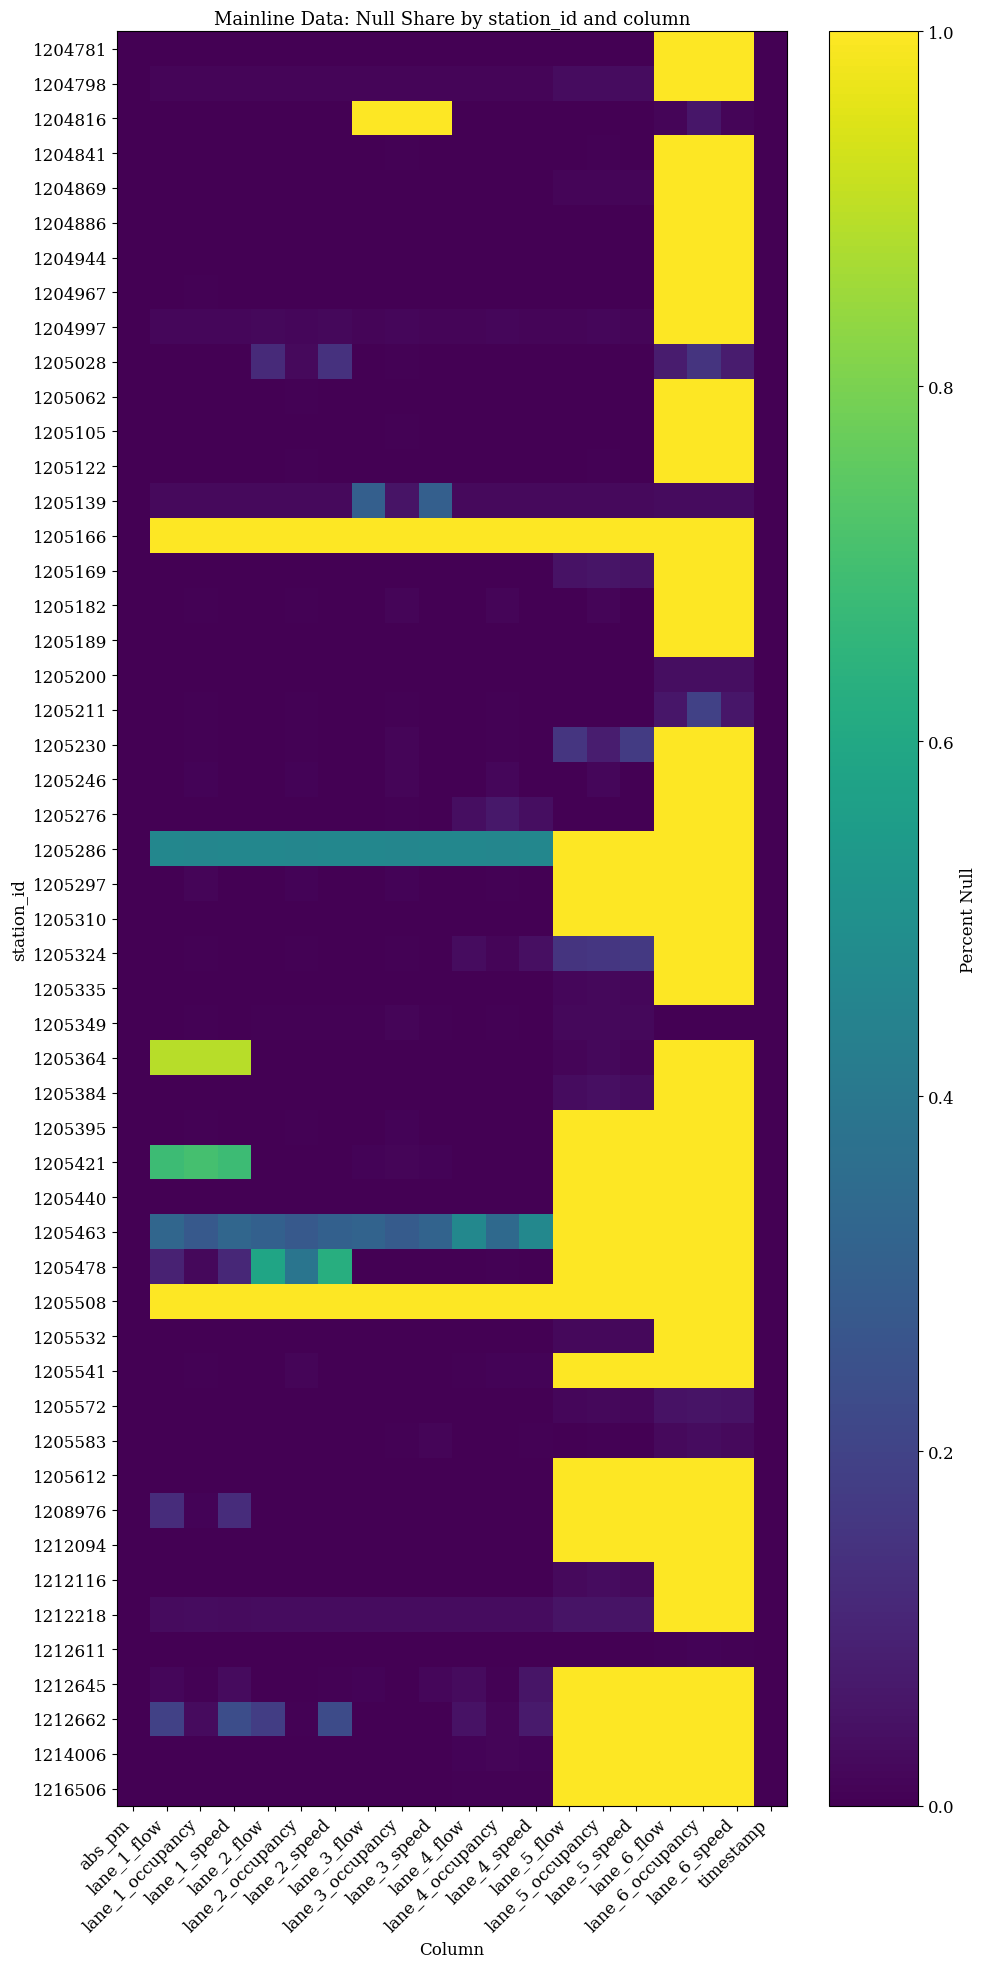

Dropping 5071 rows with no sensor data.
Summary of ML station lengths after cleaning sparse values:
 count    49.000000
mean      0.381184
std       0.142321
min       0.145000
25%       0.260000
50%       0.400000
75%       0.450000
max       0.800000
Name: length, dtype: float64

HOV Data ----------------------------------------------
HOV Data sensor readings: 97,183


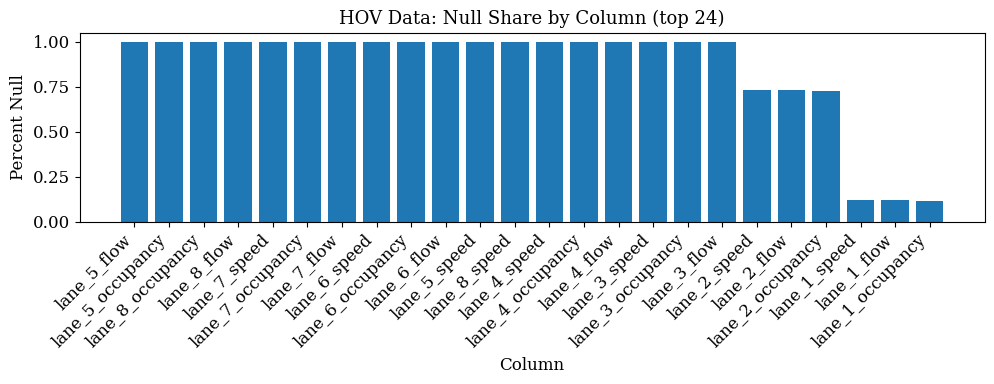

Dropping 18 fully sparse columns
HOV Data null summary (by station_id):
Total rows: 97,183


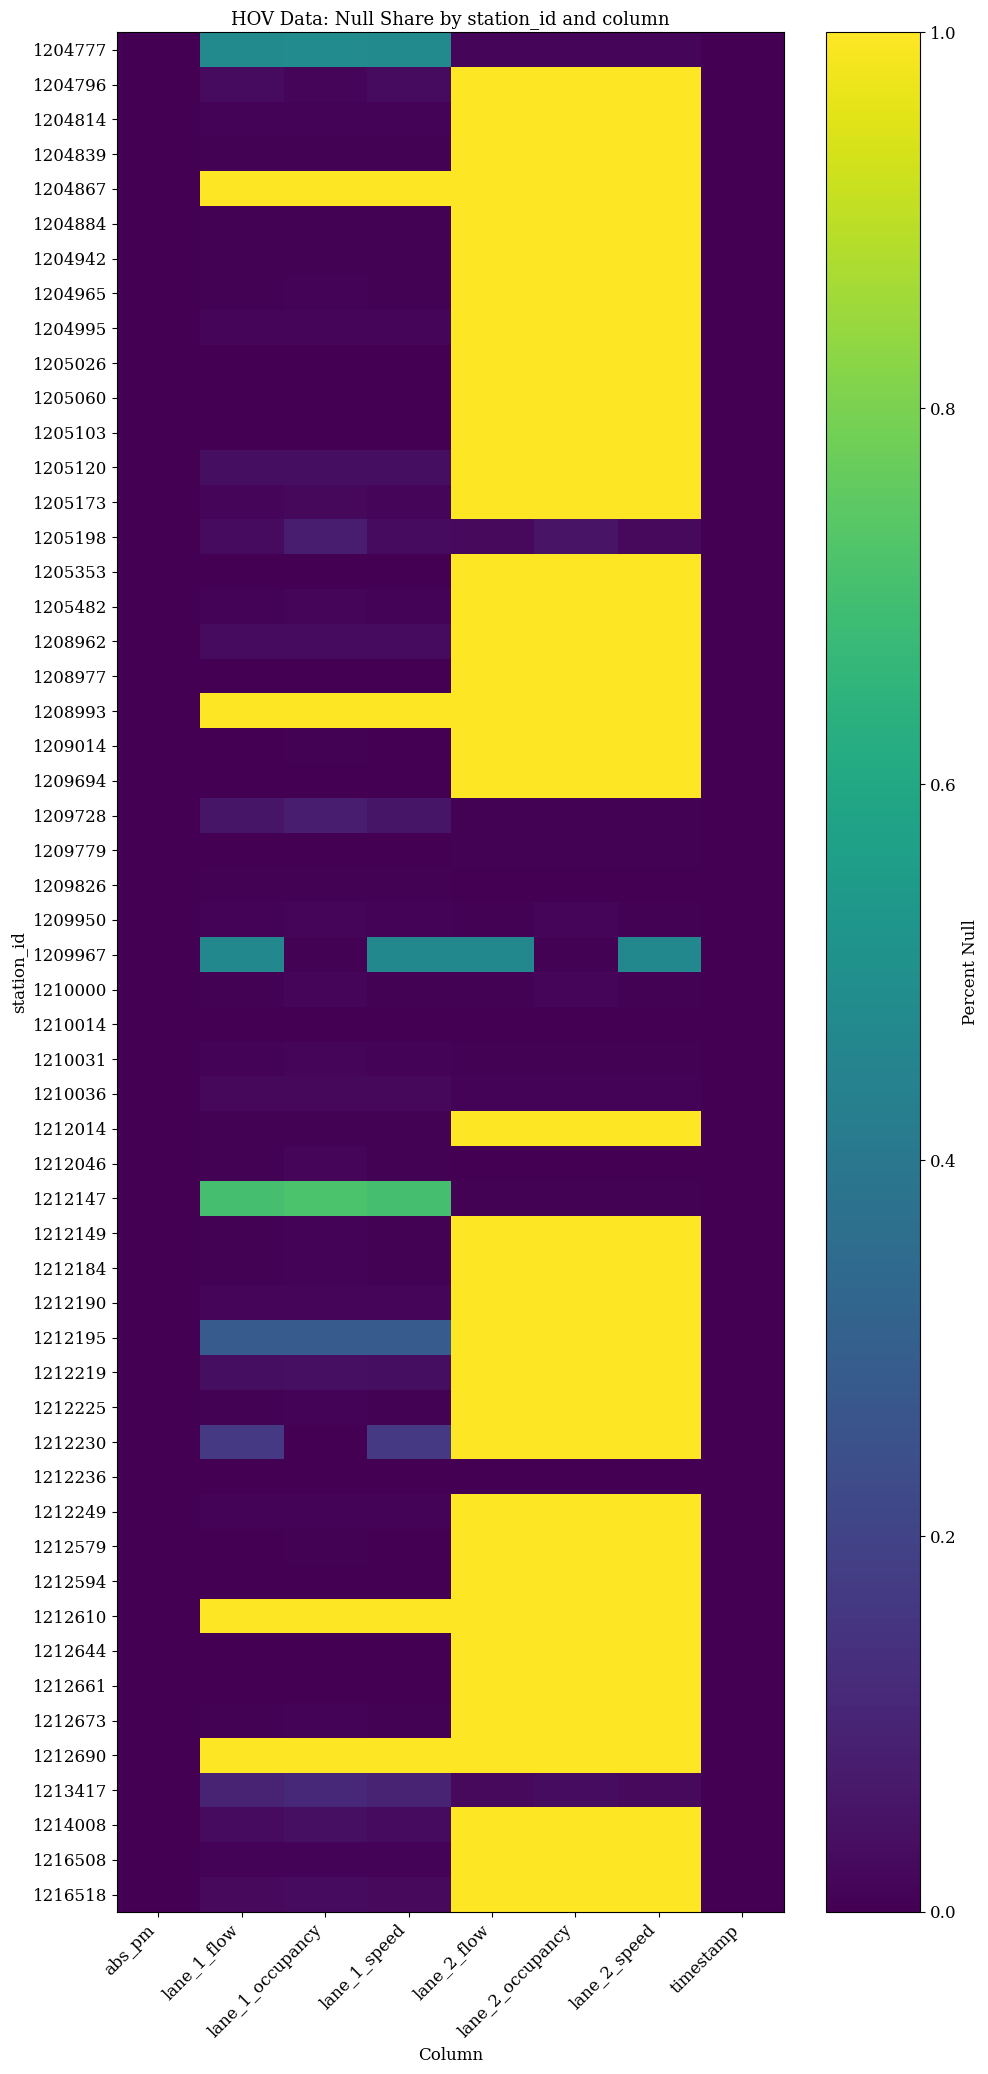

Dropping 8324 rows with no sensor data.
Summary of ML station lengths after cleaning sparse values:
 count    50.000000
mean      0.357060
std       0.140225
min       0.145000
25%       0.250000
50%       0.337500
75%       0.440000
max       0.755000
Name: length, dtype: float64

Merged HOV and ML traffic data:


,timestamp,station_id_ml,lane_1_flow_ml,lane_1_occupancy_ml,lane_1_speed_ml,lane_2_flow_ml,lane_2_occupancy_ml,lane_2_speed_ml,lane_3_flow,lane_3_occupancy,...,lane_6_occupancy,lane_6_speed,abs_pm,station_id_hov,lane_1_flow_hov,lane_1_occupancy_hov,lane_1_speed_hov,lane_2_flow_hov,lane_2_occupancy_hov,lane_2_speed_hov
0,2026-01-14 05:00:00,1204781.0,6.0,0.03,99.0,6.0,0.05,66.0,8.0,0.04,...,NaN,NaN,95.245,1204777.0,1.0,0.01,85.0,2.0,0.01,85.0
1,2026-01-14 05:00:00,1204798.0,9.0,0.06,91.0,8.0,0.05,93.0,7.0,0.08,...,NaN,NaN,95.295,1204796.0,5.0,0.20,14.0,NaN,NaN,NaN
2,2026-01-14 05:00:00,1204816.0,8.0,0.06,74.0,6.0,0.04,89.0,NaN,NaN,...,0.03,99.0,95.695,1204814.0,1.0,NaN,85.0,NaN,NaN,NaN
3,2026-01-14 05:00:00,1204841.0,7.0,0.07,48.0,4.0,0.04,45.0,3.0,0.07,...,NaN,NaN,95.885,1204839.0,5.0,0.06,51.0,NaN,NaN,NaN
4,2026-01-14 05:00:00,1204869.0,7.0,0.05,85.0,8.0,0.08,60.0,6.0,0.04,...,NaN,NaN,96.245,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# --- Mainline detectors -----------------------------------------------------
print('Mainline Data ----------------------------------------------')
ml_ids = ml_stations["station_id"].unique()
ml_data = demand[demand["station_id"].isin(ml_ids)].copy()

ml_column_sparsity = summarize_sparsity(ml_data, label='Mainline Data', mode='column_nulls')
# ml_detector_sparsity = summarize_sparsity(ml_data, label='Mainline Data', mode='lane_all_null_by_id')

# get column names that have 100% sparsity
fully_sparse_cols = ml_column_sparsity[ml_column_sparsity['percent_null'] == 1.0]['column'].tolist()
print("Dropping", len(fully_sparse_cols), "fully sparse columns")

# Remove fully sparse columns
ml_data.drop(columns=fully_sparse_cols, inplace=True)

ml_station_sparsity = summarize_sparsity(ml_data, label='Mainline Data', mode='by_station', group_col='station_id')

# Drop rows with no lane data (keeping timestamp/station_id)
num_dropped_rows = ml_data[ml_data.columns.difference(["timestamp", "station_id", "abs_pm"])].isna().all(axis=1).sum()
print("Dropping", num_dropped_rows, "rows with no sensor data.")
ml_data.dropna(how="all", subset=ml_data.columns.difference(["timestamp", "station_id", "abs_pm"]), inplace=True)

# Summarize lengths between ML detectors AFTER dropping sparse detectors
ml_ids = ml_data["station_id"].unique()
ml_stations = ml_stations[ml_stations["station_id"].isin(ml_ids)].copy()
print("Summary of ML station lengths after cleaning sparse values:\n", ml_stations["length"].describe())

# --- HOV / Managed-lane detectors ------------------------------------------
print('')
print('HOV Data ----------------------------------------------')
hov_ids = hov_stations["station_id"].unique()
hov_data = demand[demand["station_id"].isin(hov_ids)].copy()

hov_column_sparsity = summarize_sparsity(hov_data, label='HOV Data', mode='column_nulls')
# hov_detector_sparsity = summarize_sparsity(hov_data, label='HOV Data', mode='lane_all_null_by_id')

# Get column names that have 100% sparsity
fully_sparse_cols = hov_column_sparsity[hov_column_sparsity['percent_null'] == 1.0]['column'].tolist()
print("Dropping", len(fully_sparse_cols), "fully sparse columns")

# Drop all columns with full sparsity
hov_data.drop(columns=fully_sparse_cols, inplace=True)

hov_station_sparsity = summarize_sparsity(hov_data, label='HOV Data', mode='by_station', group_col='station_id')

# Drop rows with no lane data (keeping timestamp/station_id)
num_dropped_rows = hov_data[hov_data.columns.difference(["timestamp", "station_id", "abs_pm"])].isna().all(axis=1).sum()
print("Dropping", num_dropped_rows, "rows with no sensor data.")
hov_data.dropna(how="all", subset=hov_data.columns.difference(["timestamp", "station_id", "abs_pm"]), inplace=True)

# Summarize lengths between HOV detectors AFTER dropping sparse detectors
hov_ids = hov_data["station_id"].unique()
hov_stations = hov_stations[hov_stations["station_id"].isin(hov_ids)].copy()
print("Summary of ML station lengths after cleaning sparse values:\n", hov_stations["length"].describe())

# Merge mainline + HOV data on the shared postmile/timestamp grid.
all_data = ml_data.merge(hov_data, on=["timestamp", "abs_pm"], how="outer", suffixes=("_ml", "_hov"))
print()
print('Merged HOV and ML traffic data:')
all_data.head()

### 1.5 Build Flow Observations


In [37]:
# Keep only flow-related columns (drop occupancy/speed).
flow_cols = all_data.columns[~all_data.columns.str.contains("occupancy|speed", case=False)]
flow = all_data.loc[:, flow_cols].copy()

# Identify all flow columns once for reuse.
flow_measure_cols = [col for col in flow.columns if "flow" in col.lower()]

# Aggregate total flow (vehicles / 30s) across all available lanes.
flow["total_flow"] = flow[flow_measure_cols].sum(axis=1)

# Count how many lanes report valid flow on each row.
flow["num_lanes"] = flow[flow_measure_cols].notna().sum(axis=1)

# Normalize per lane per hour (30-second interval -> multiply by 120).
flow["flow_per_lane_per_hour"] = flow["total_flow"] / flow["num_lanes"] * 120

flow.head()

,timestamp,station_id_ml,lane_1_flow_ml,lane_2_flow_ml,lane_3_flow,lane_4_flow,lane_5_flow,lane_6_flow,abs_pm,station_id_hov,lane_1_flow_hov,lane_2_flow_hov,total_flow,num_lanes,flow_per_lane_per_hour
0,2026-01-14 05:00:00,1204781.0,6.0,6.0,8.0,4.0,8.0,NaN,95.245,1204777.0,1.0,2.0,35.0,7,600.0
1,2026-01-14 05:00:00,1204798.0,9.0,8.0,7.0,7.0,2.0,NaN,95.295,1204796.0,5.0,NaN,38.0,6,760.0
2,2026-01-14 05:00:00,1204816.0,8.0,6.0,NaN,5.0,5.0,8.0,95.695,1204814.0,1.0,NaN,33.0,6,660.0
3,2026-01-14 05:00:00,1204841.0,7.0,4.0,3.0,8.0,6.0,NaN,95.885,1204839.0,5.0,NaN,33.0,6,660.0
4,2026-01-14 05:00:00,1204869.0,7.0,8.0,6.0,4.0,5.0,NaN,96.245,NaN,NaN,NaN,30.0,5,720.0


### 1.6 Build Speed Observations


In [38]:
# Keep only speed-related columns (drop any flow or occupancy metrics).
speed_cols = all_data.columns[~all_data.columns.str.contains("occupancy|flow", case=False)]
speed = all_data.loc[:, speed_cols].copy()

# Identify all speed columns once for reuse.
speed_measure_cols = [col for col in speed.columns if "speed" in col.lower()]

# Compute the per-row average speed across available lanes.
speed["avg_speed"] = speed[speed_measure_cols].mean(axis=1)

speed.head()

,timestamp,station_id_ml,lane_1_speed_ml,lane_2_speed_ml,lane_3_speed,lane_4_speed,lane_5_speed,lane_6_speed,abs_pm,station_id_hov,lane_1_speed_hov,lane_2_speed_hov,avg_speed
0,2026-01-14 05:00:00,1204781.0,99.0,66.0,99.0,33.0,29.0,NaN,95.245,1204777.0,85.0,85.0,70.857143
1,2026-01-14 05:00:00,1204798.0,91.0,93.0,51.0,43.0,29.0,NaN,95.295,1204796.0,14.0,NaN,53.500000
2,2026-01-14 05:00:00,1204816.0,74.0,89.0,NaN,41.0,37.0,99.0,95.695,1204814.0,85.0,NaN,70.833333
3,2026-01-14 05:00:00,1204841.0,48.0,45.0,20.0,32.0,82.0,NaN,95.885,1204839.0,51.0,NaN,46.333333
4,2026-01-14 05:00:00,1204869.0,85.0,60.0,84.0,65.0,83.0,NaN,96.245,NaN,NaN,NaN,75.400000


### 1.7 Perform Gridding into Time-Space Matrices

In [ ]:
# Grid detector observations into matrices with rows=space and cols=time.
# The output paths are defined once in CONFIG.

# --- PeMS gridding parameters -------------------------------------------------
time_increment_seconds = TIME_INCREMENT_SECONDS
time_col = "timestamp"
postmile_col = "abs_pm"

# --- Build speed/flow matrices -----------------------------------------------
speed_matrix, speed_df = process_pems(
    speed,
    time_col=time_col,
    postmile_col=postmile_col,
    value_col="avg_speed",
    start_pm=start_pm,
    end_pm=end_pm,
    time_interval=time_increment_seconds,
    space_interval=SPACE_STEP_MI
)

flow_matrix, flow_df = process_pems(
    flow,
    time_col=time_col,
    postmile_col=postmile_col,
    value_col="flow_per_lane_per_hour",
    start_pm=start_pm,
    end_pm=end_pm,
    time_interval=time_increment_seconds,
    space_interval=SPACE_STEP_MI
)

# Save flow and speed dfs to csv if desired
# speed_df.to_csv(array_dir / "v_hat_raw", index=False)
# flow_df.to_csv(array_dir / "q_hat_raw", index=False)

### 1.8 Visualize Raw Gridded Matrices


inferred time increment: 0 days 00:00:30
inferred space increment: -0.4 km
num time bins: 1799
num space bins: 80
num space edges: 80


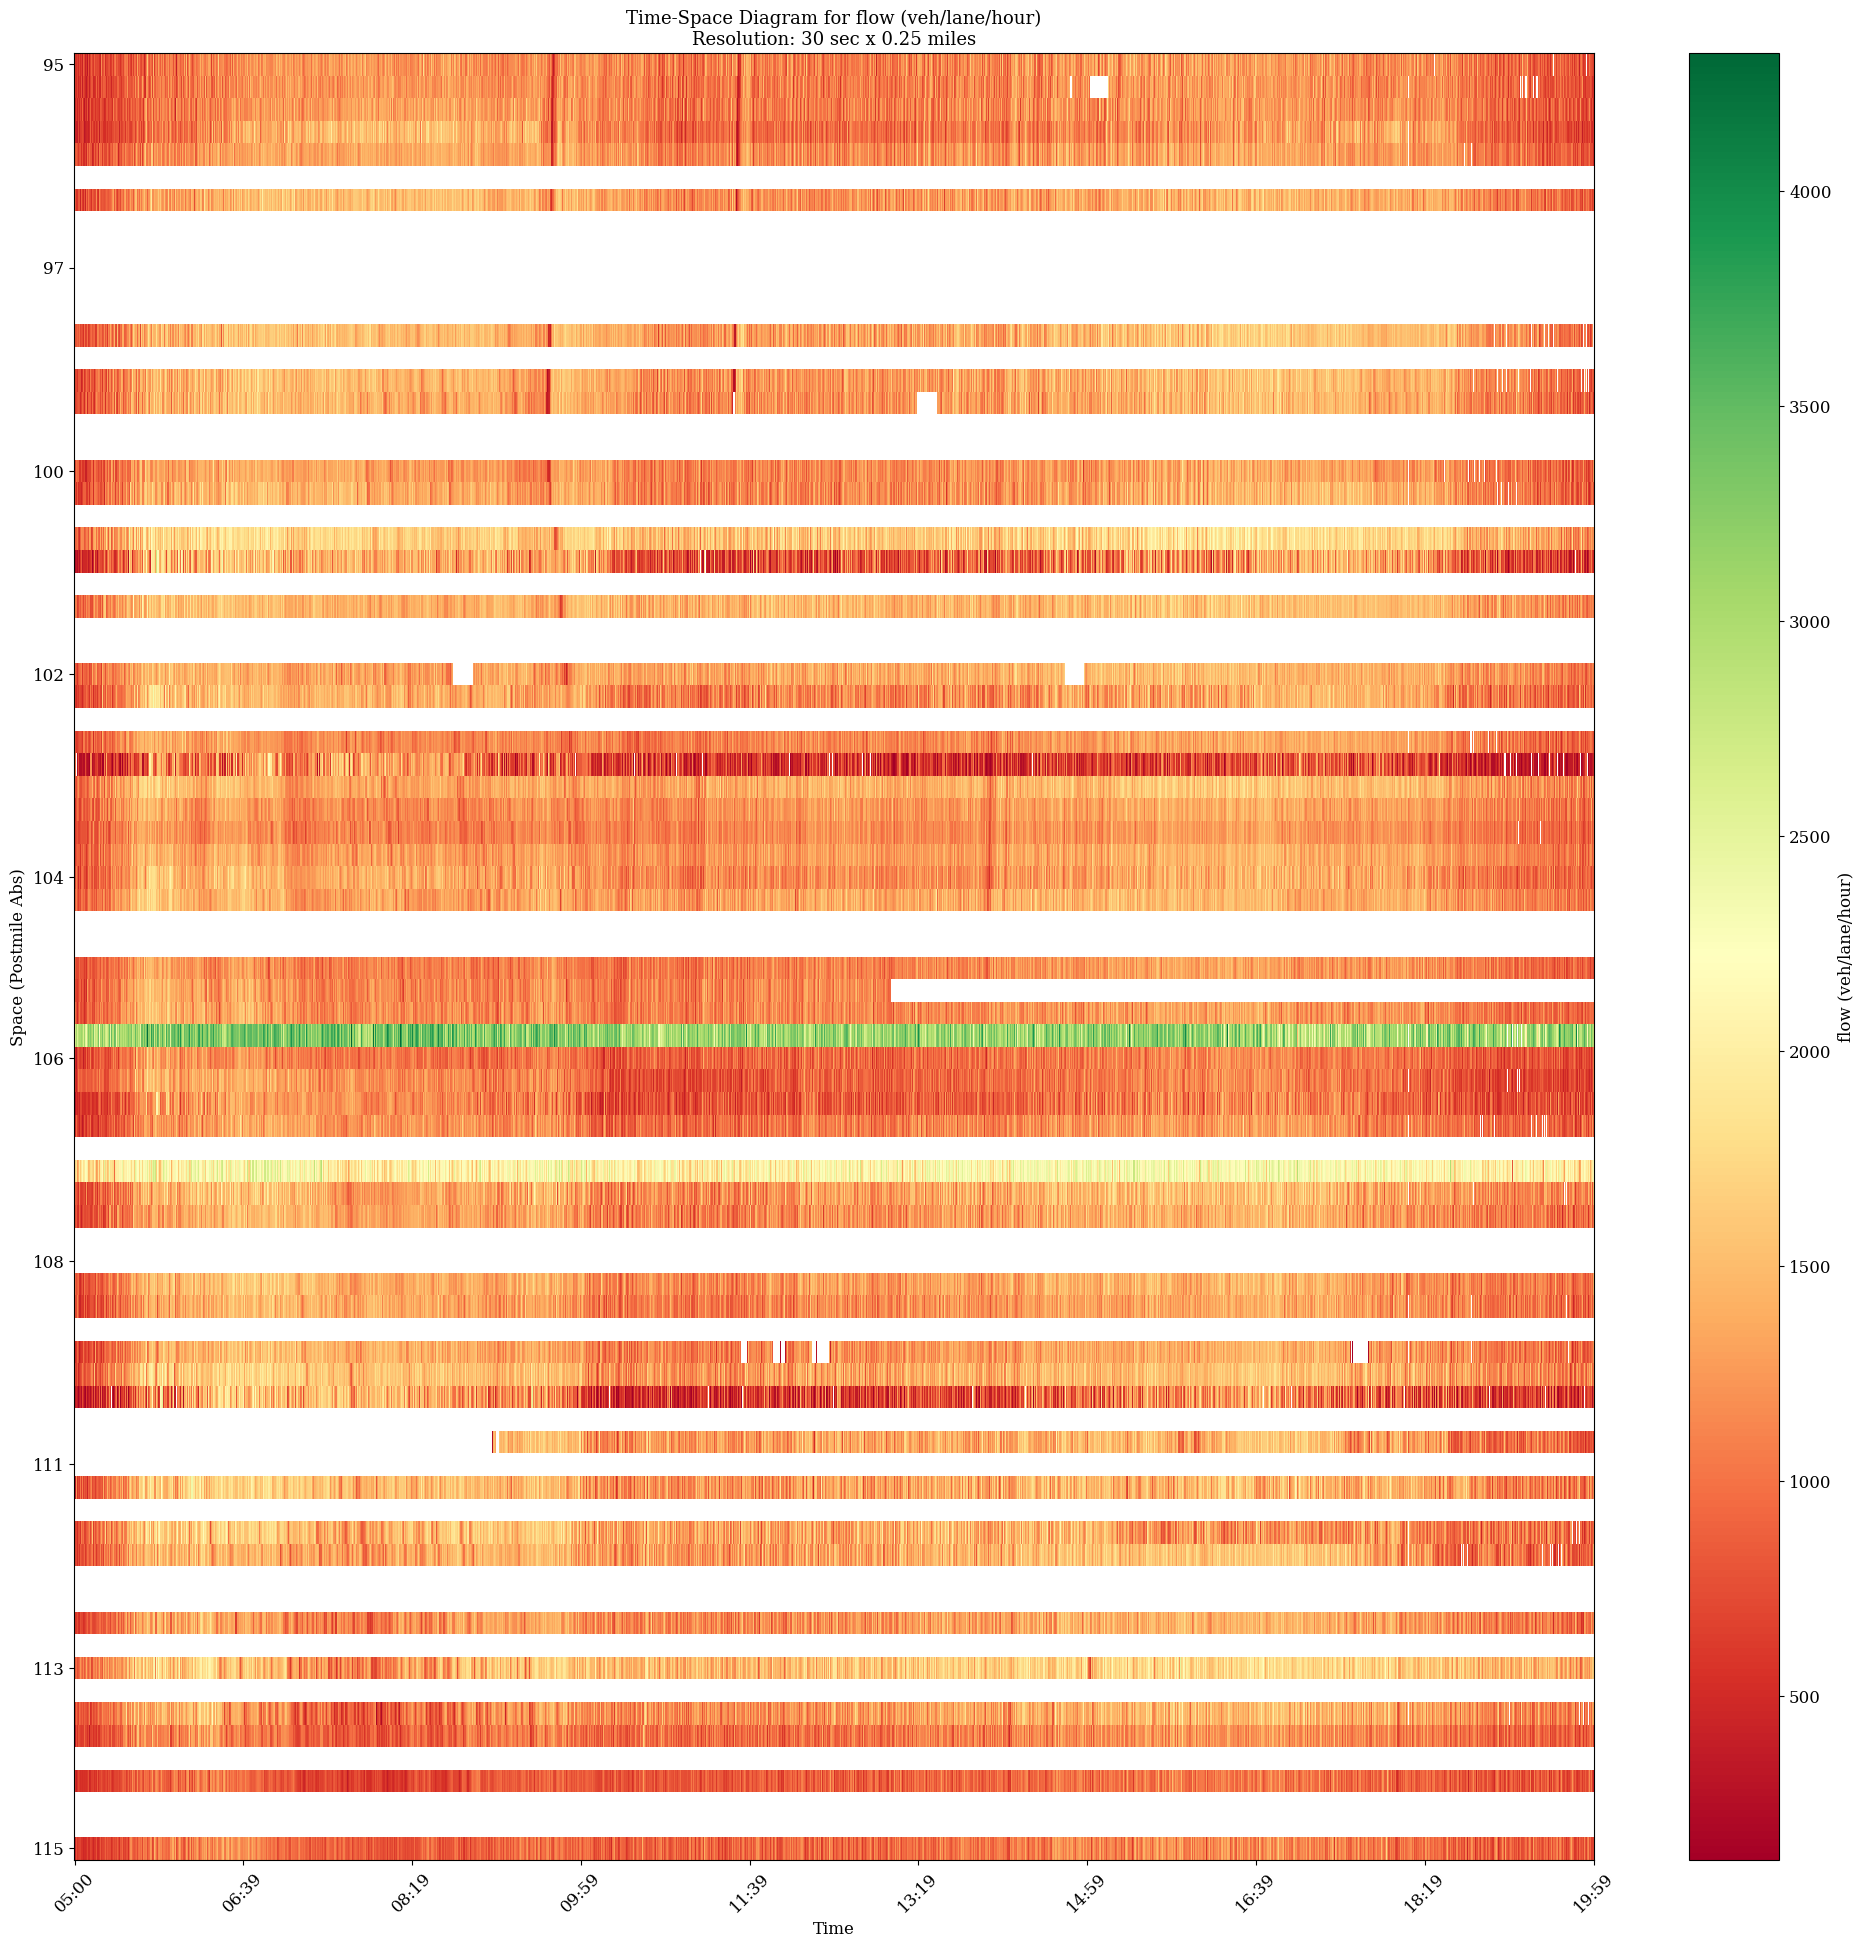

inferred time increment: 0 days 00:00:30
inferred space increment: -0.4 km
num time bins: 1799
num space bins: 80
num space edges: 80


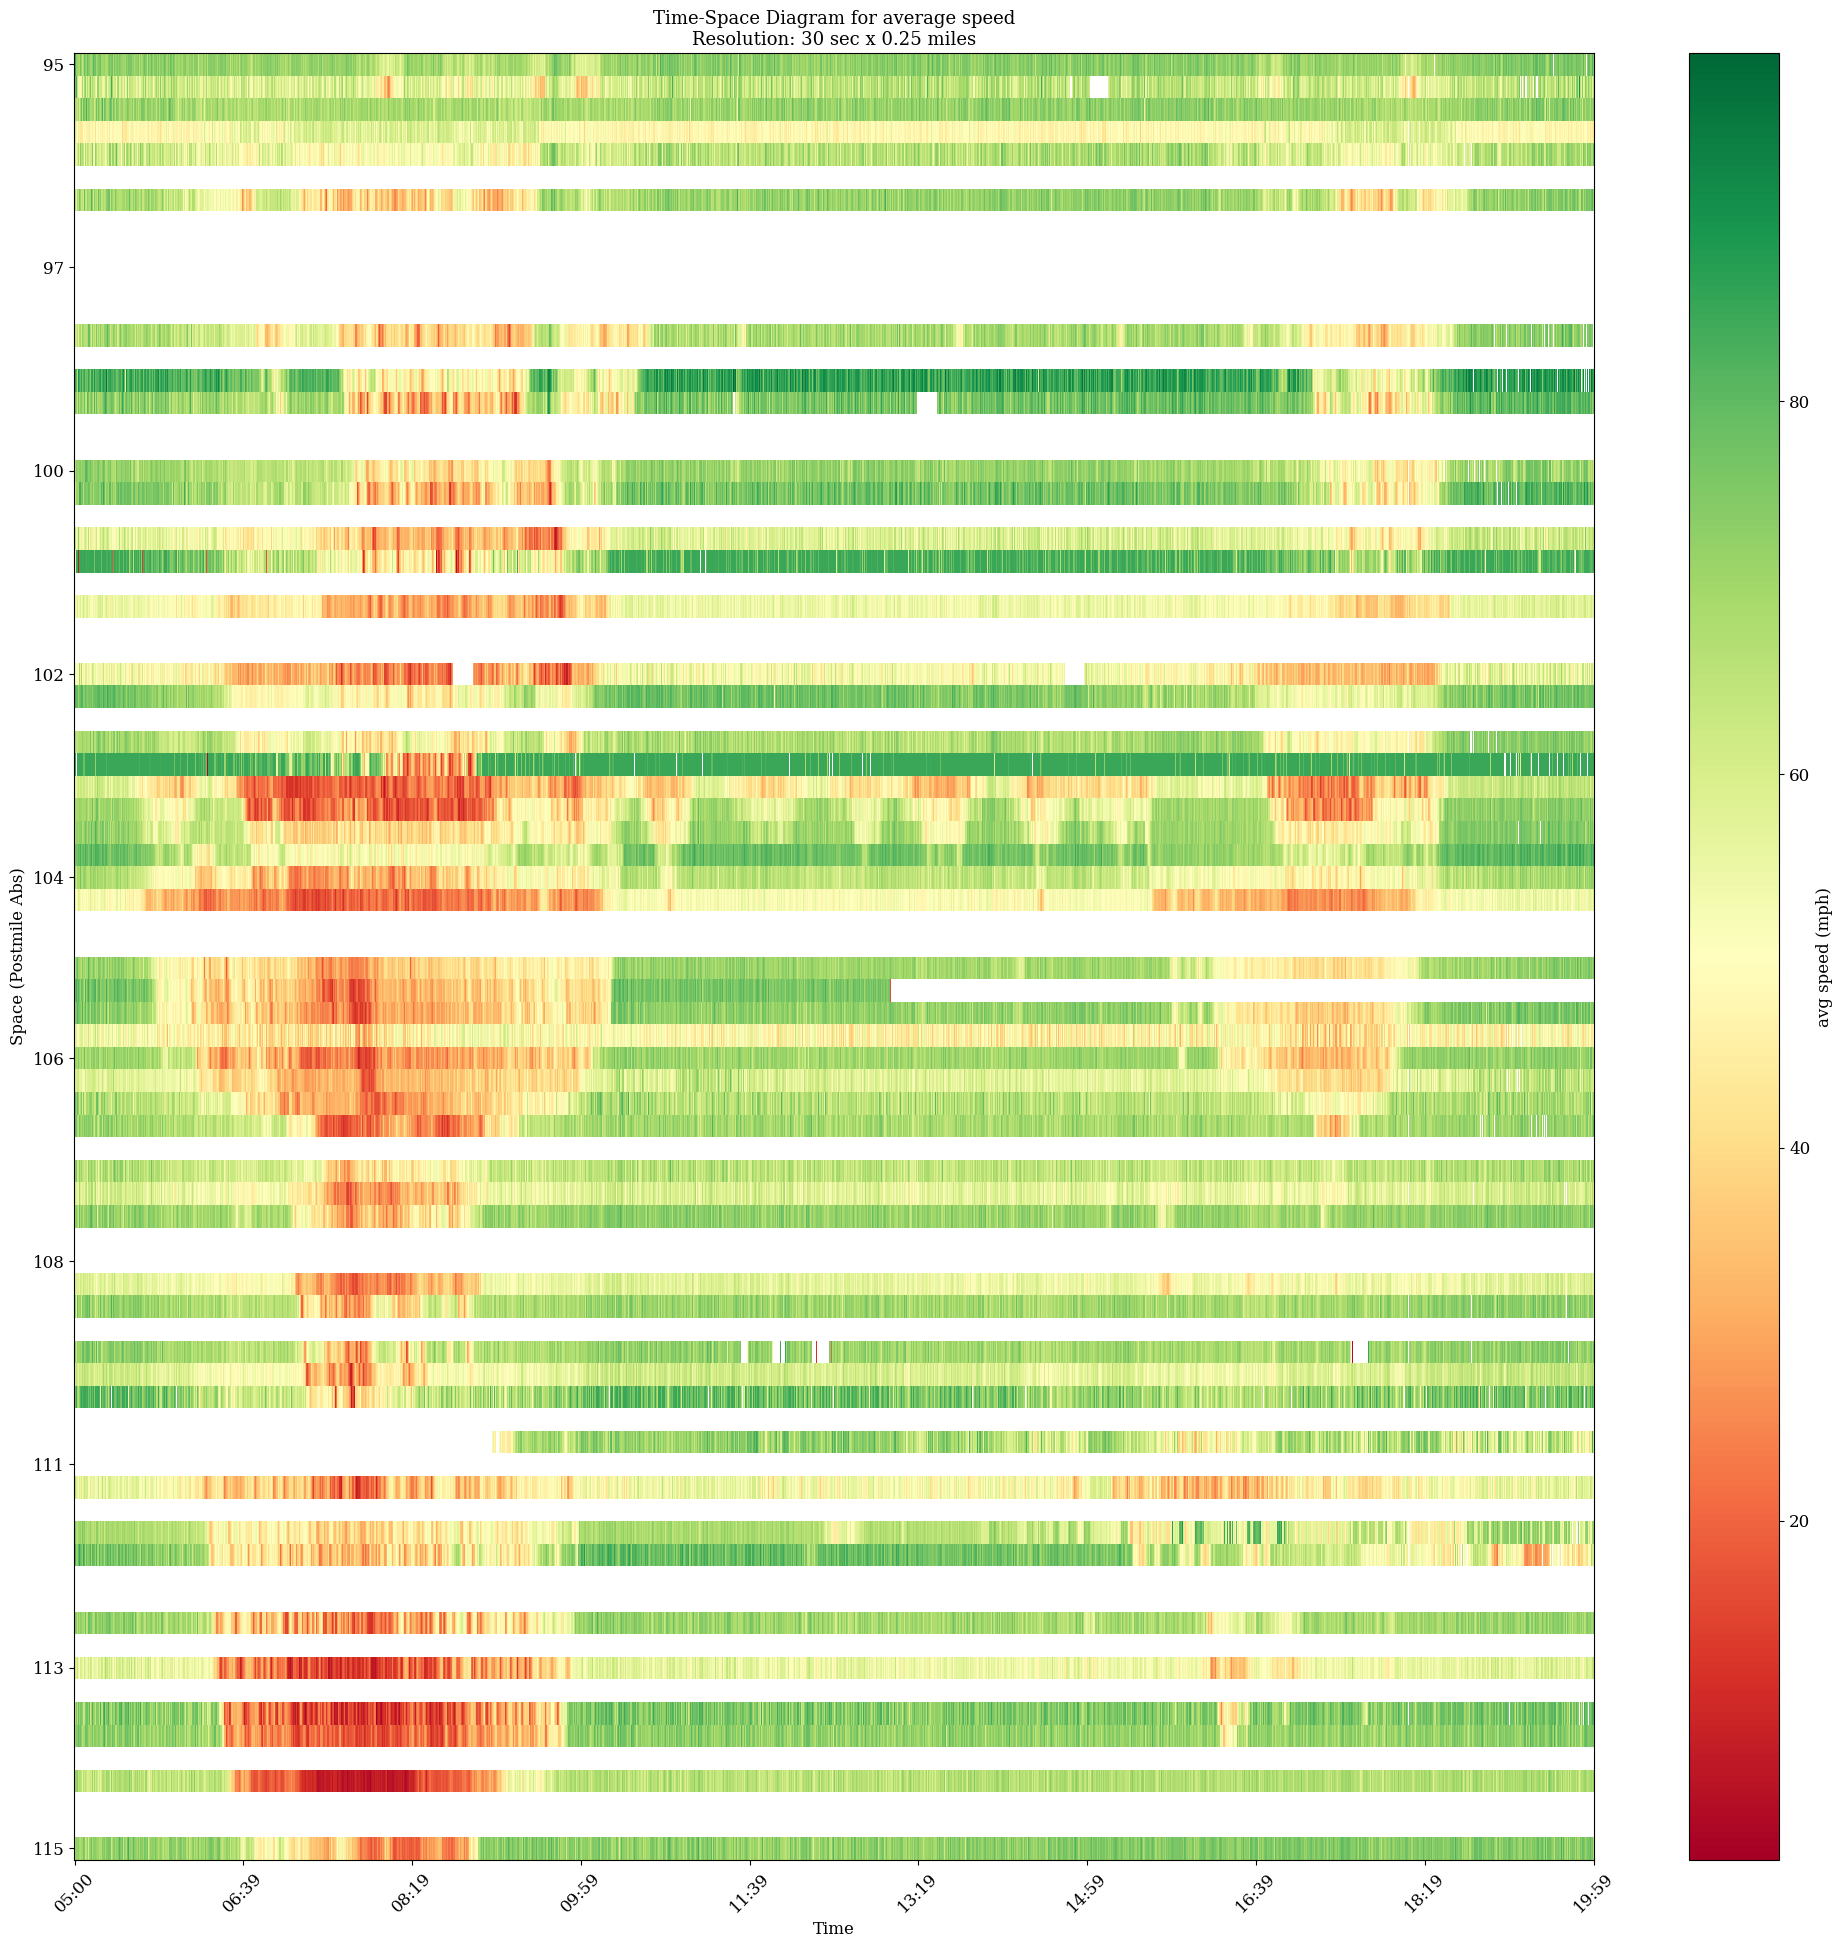

In [40]:
t_min = flow[time_col].min()
t_max = flow[time_col].max()

plot_matrix(flow_matrix, "flow (veh/lane/hour)", t_min = t_min, t_max = t_max, start_pm = start_pm, end_pm = end_pm)
plot_matrix(speed_matrix, "average speed", "avg speed (mph)", t_min, t_max, start_pm, end_pm)

### 3.1 Increase the resolution of the gridded data

In [41]:
# Upsample the gridded matrices before running ASMx.
# Spatial / temporal refinement and physics parameters come from CONFIG["asmx"].
flow_matrix = increase_resolution(flow_matrix, SPACE_FACTOR, TIME_FACTOR)
speed_matrix = increase_resolution(speed_matrix, SPACE_FACTOR, TIME_FACTOR)

# Update time/space resolution after refinement.
time_increment_seconds = time_increment_seconds / TIME_FACTOR
space_increment_miles = SPACE_STEP_MI / SPACE_FACTOR
time_increment_minutes = time_increment_seconds.total_seconds() / 60
DT = time_increment_seconds.total_seconds()

inferred time increment: 0 days 00:00:10
inferred space increment: -0.4 km
num time bins: 5397
num space bins: 80
num space edges: 80


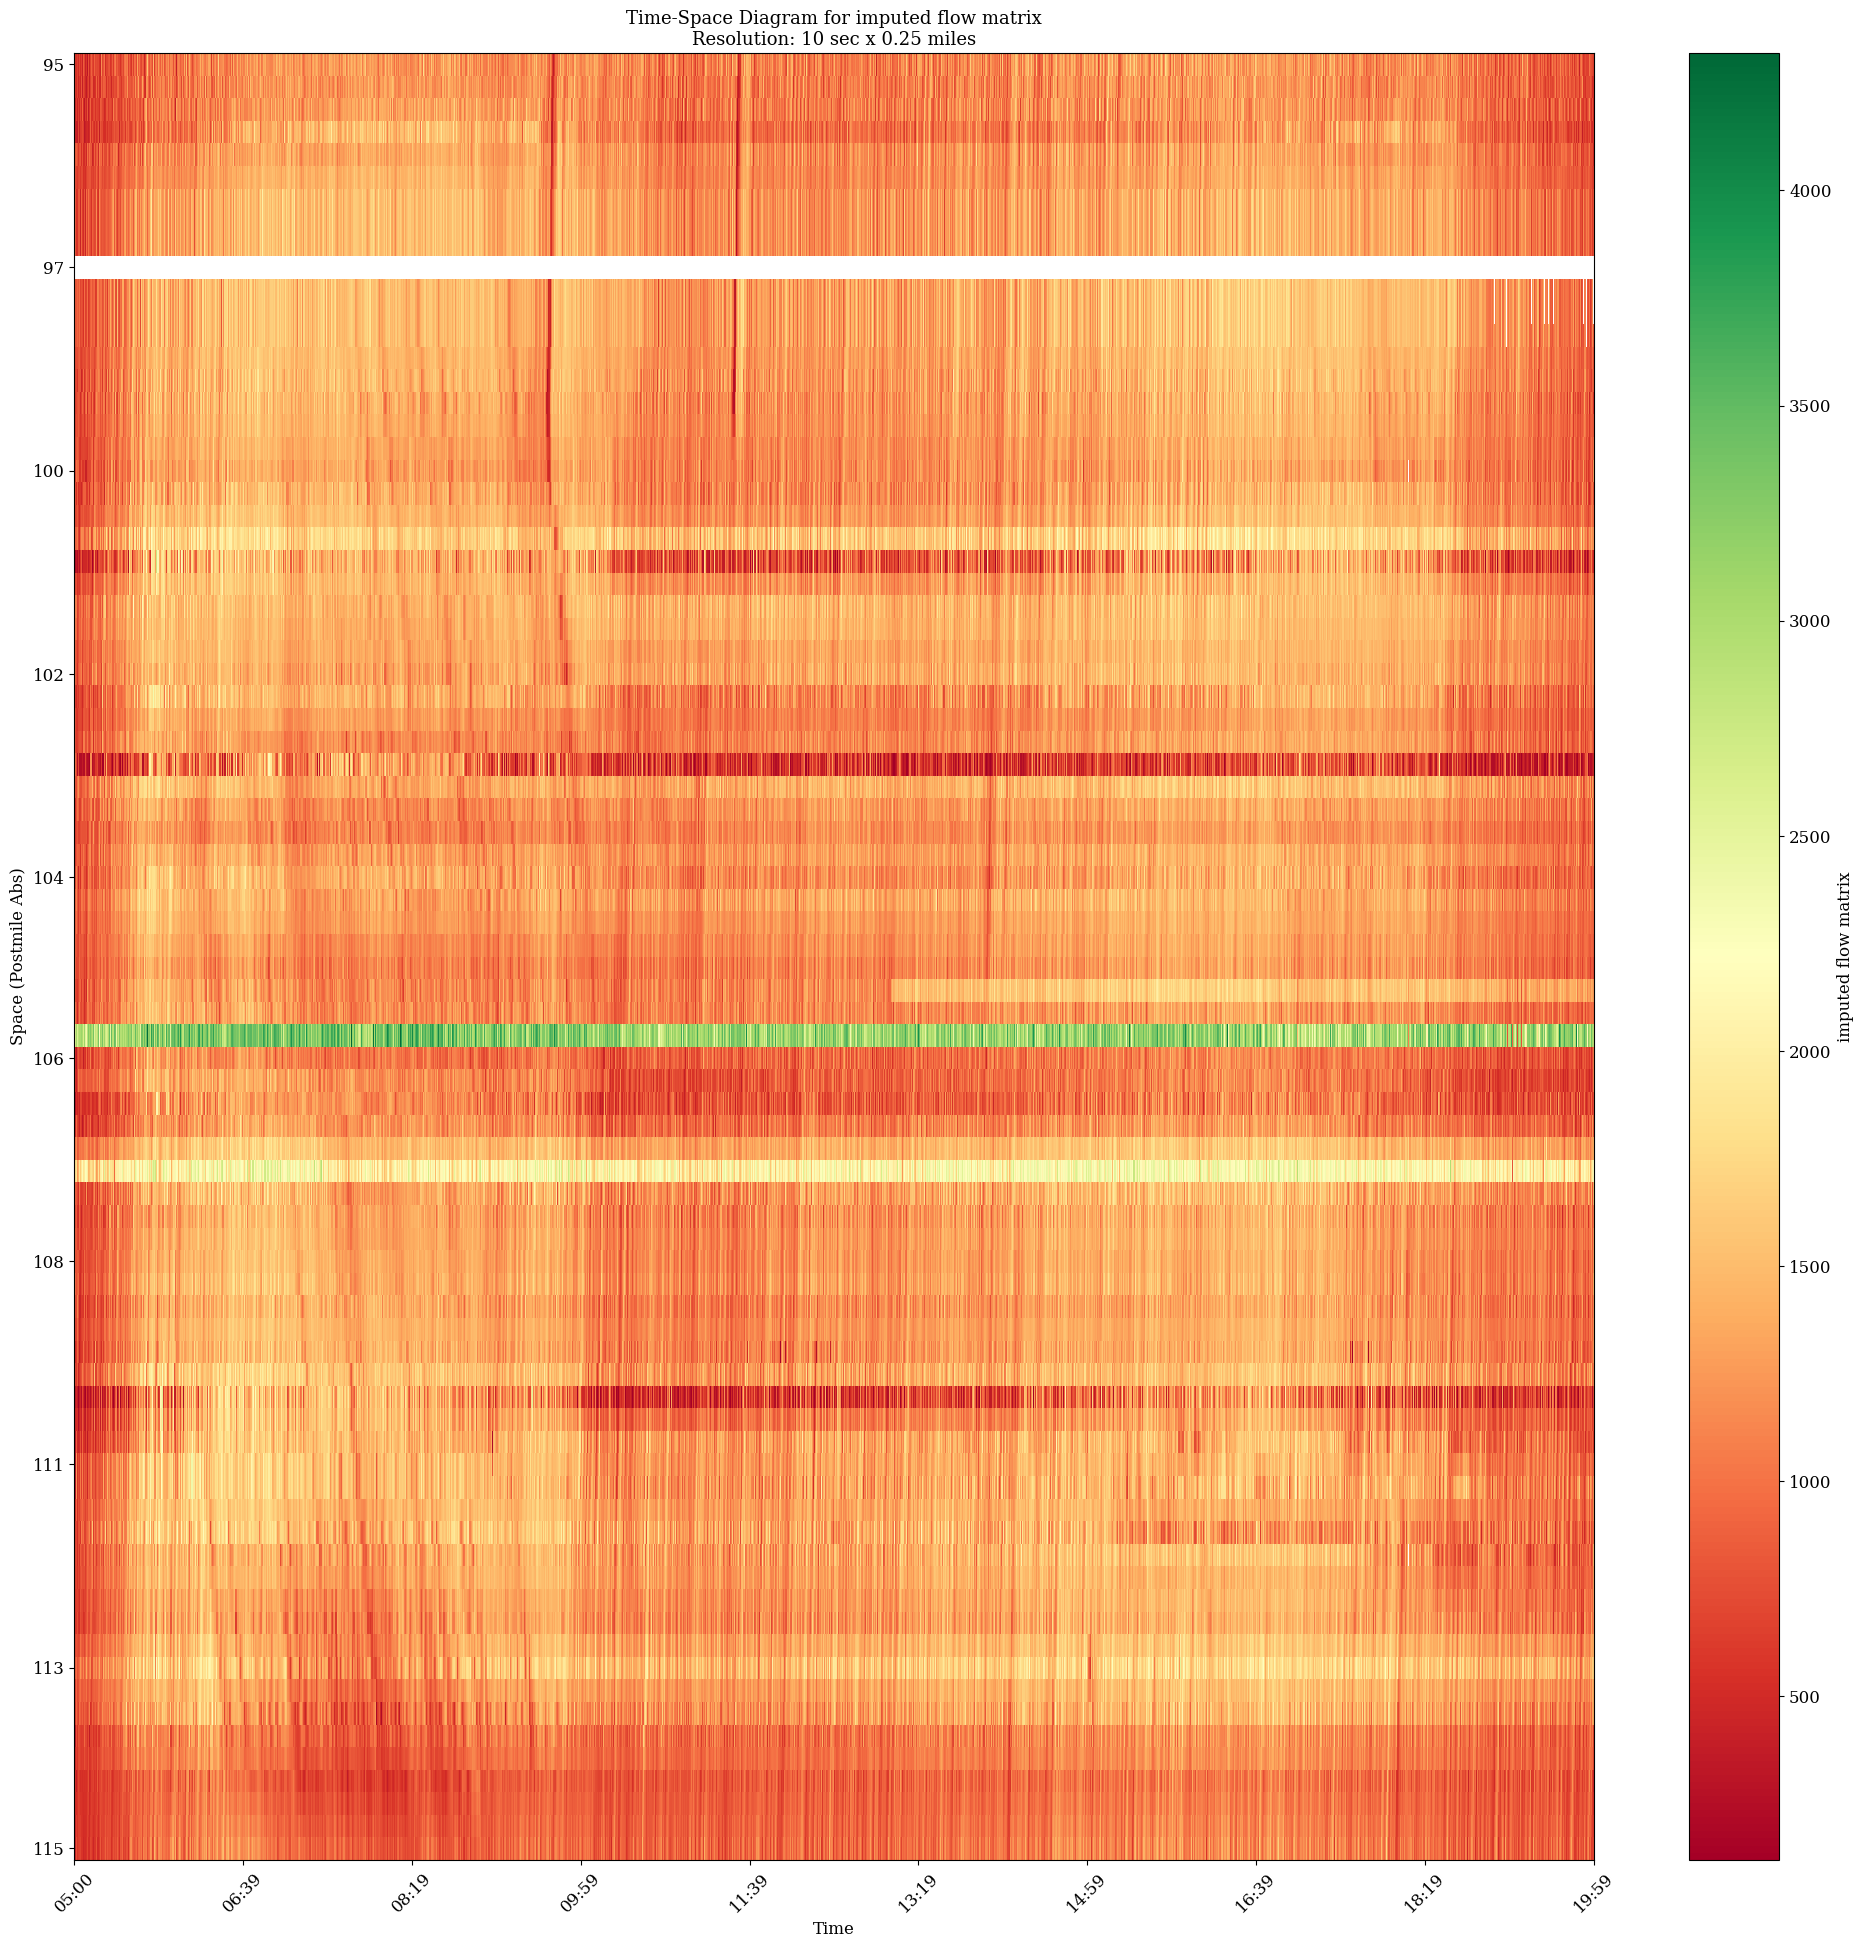

inferred time increment: 0 days 00:00:10
inferred space increment: -0.4 km
num time bins: 5397
num space bins: 80
num space edges: 80


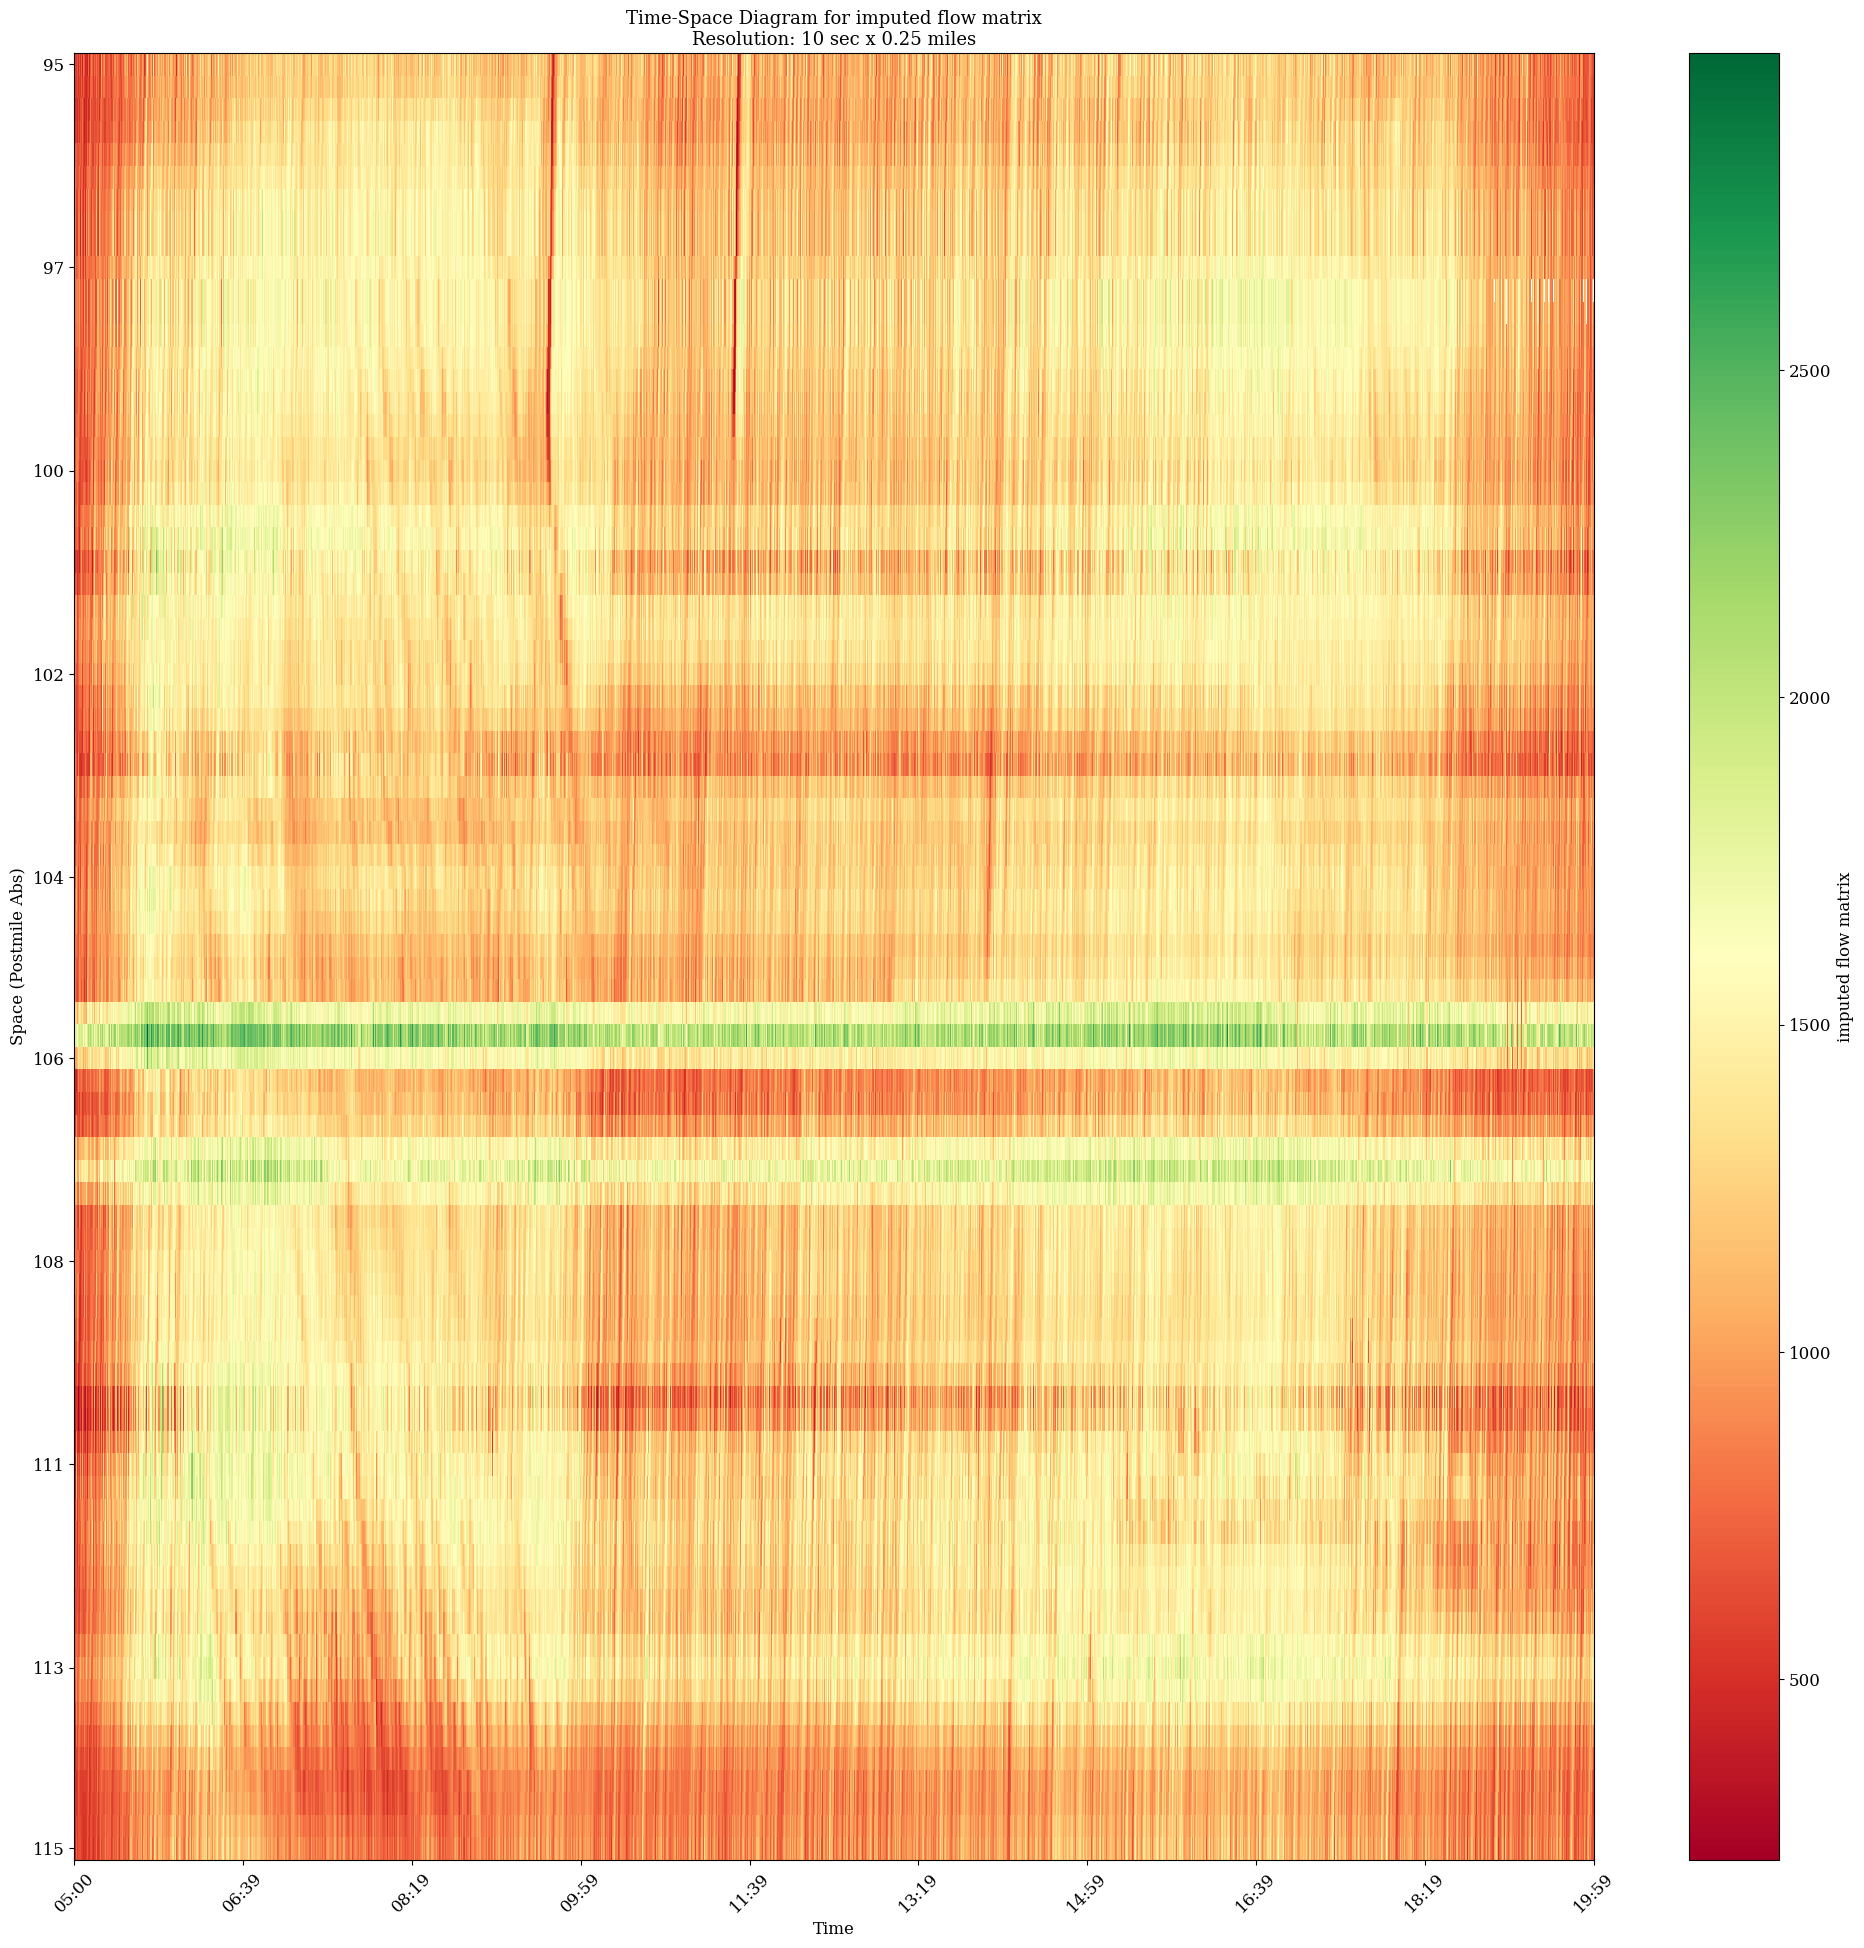

In [49]:
from pems.pems_utils import y_weighted_fill_or_smooth
flow_matrix_imputed = y_weighted_fill_or_smooth(flow_matrix, 'impute', num_neighbors = 2, max_passes=1)
plot_matrix(flow_matrix_imputed, 'imputed flow matrix', t_min=t_min,t_max=t_max, start_pm=start_pm, end_pm=end_pm)
flow_matrix_smoothed = y_weighted_fill_or_smooth(flow_matrix_imputed, 'smooth', num_neighbors=1, max_passes=1)
plot_matrix(flow_matrix_smoothed, 'imputed flow matrix', t_min=t_min,t_max=t_max, start_pm=start_pm, end_pm=end_pm)

,matrix,shape,min,max
0,q_hat,"(5397, 80)",1256.036727,18357.808577
1,v_hat,"(5397, 80)",7.166251,150.197449
2,rho_hat,"(5397, 80)",10.370953,512.844575


inferred time increment: 0 days 00:00:10
inferred space increment: -0.4 km
num time bins: 5397
num space bins: 80
num space edges: 80


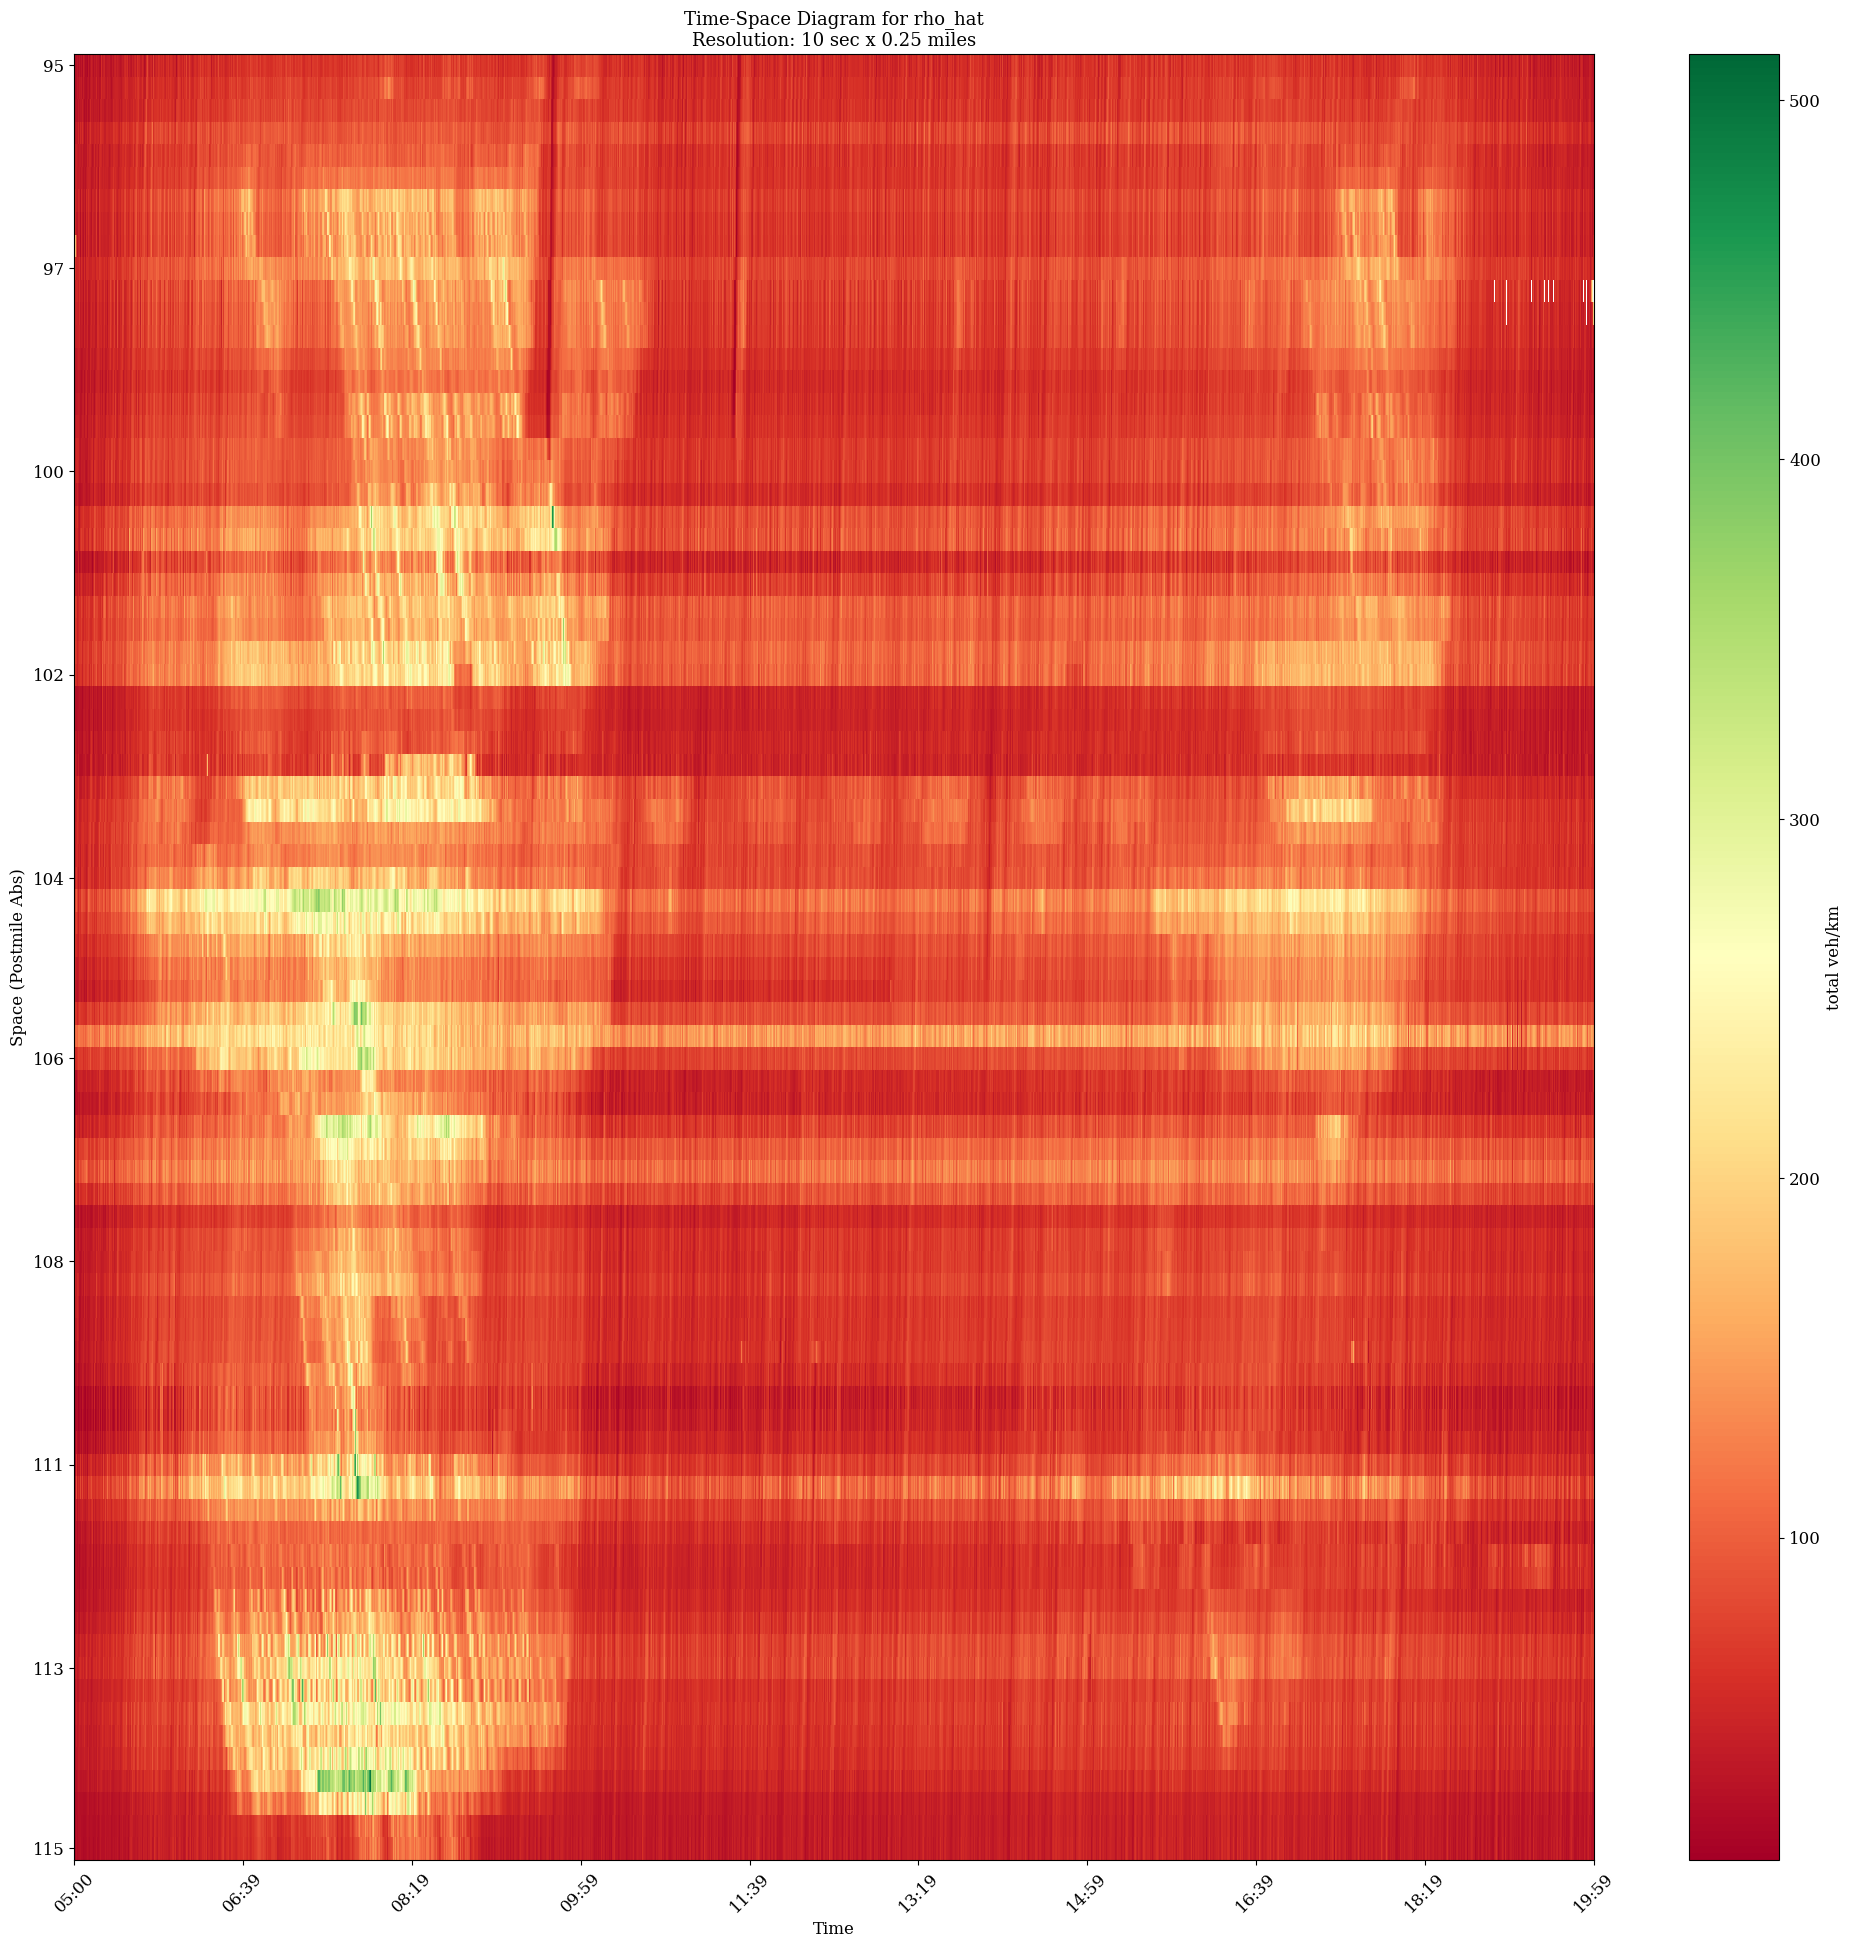

inferred time increment: 0 days 00:00:10
inferred space increment: -0.4 km
num time bins: 5397
num space bins: 80
num space edges: 80


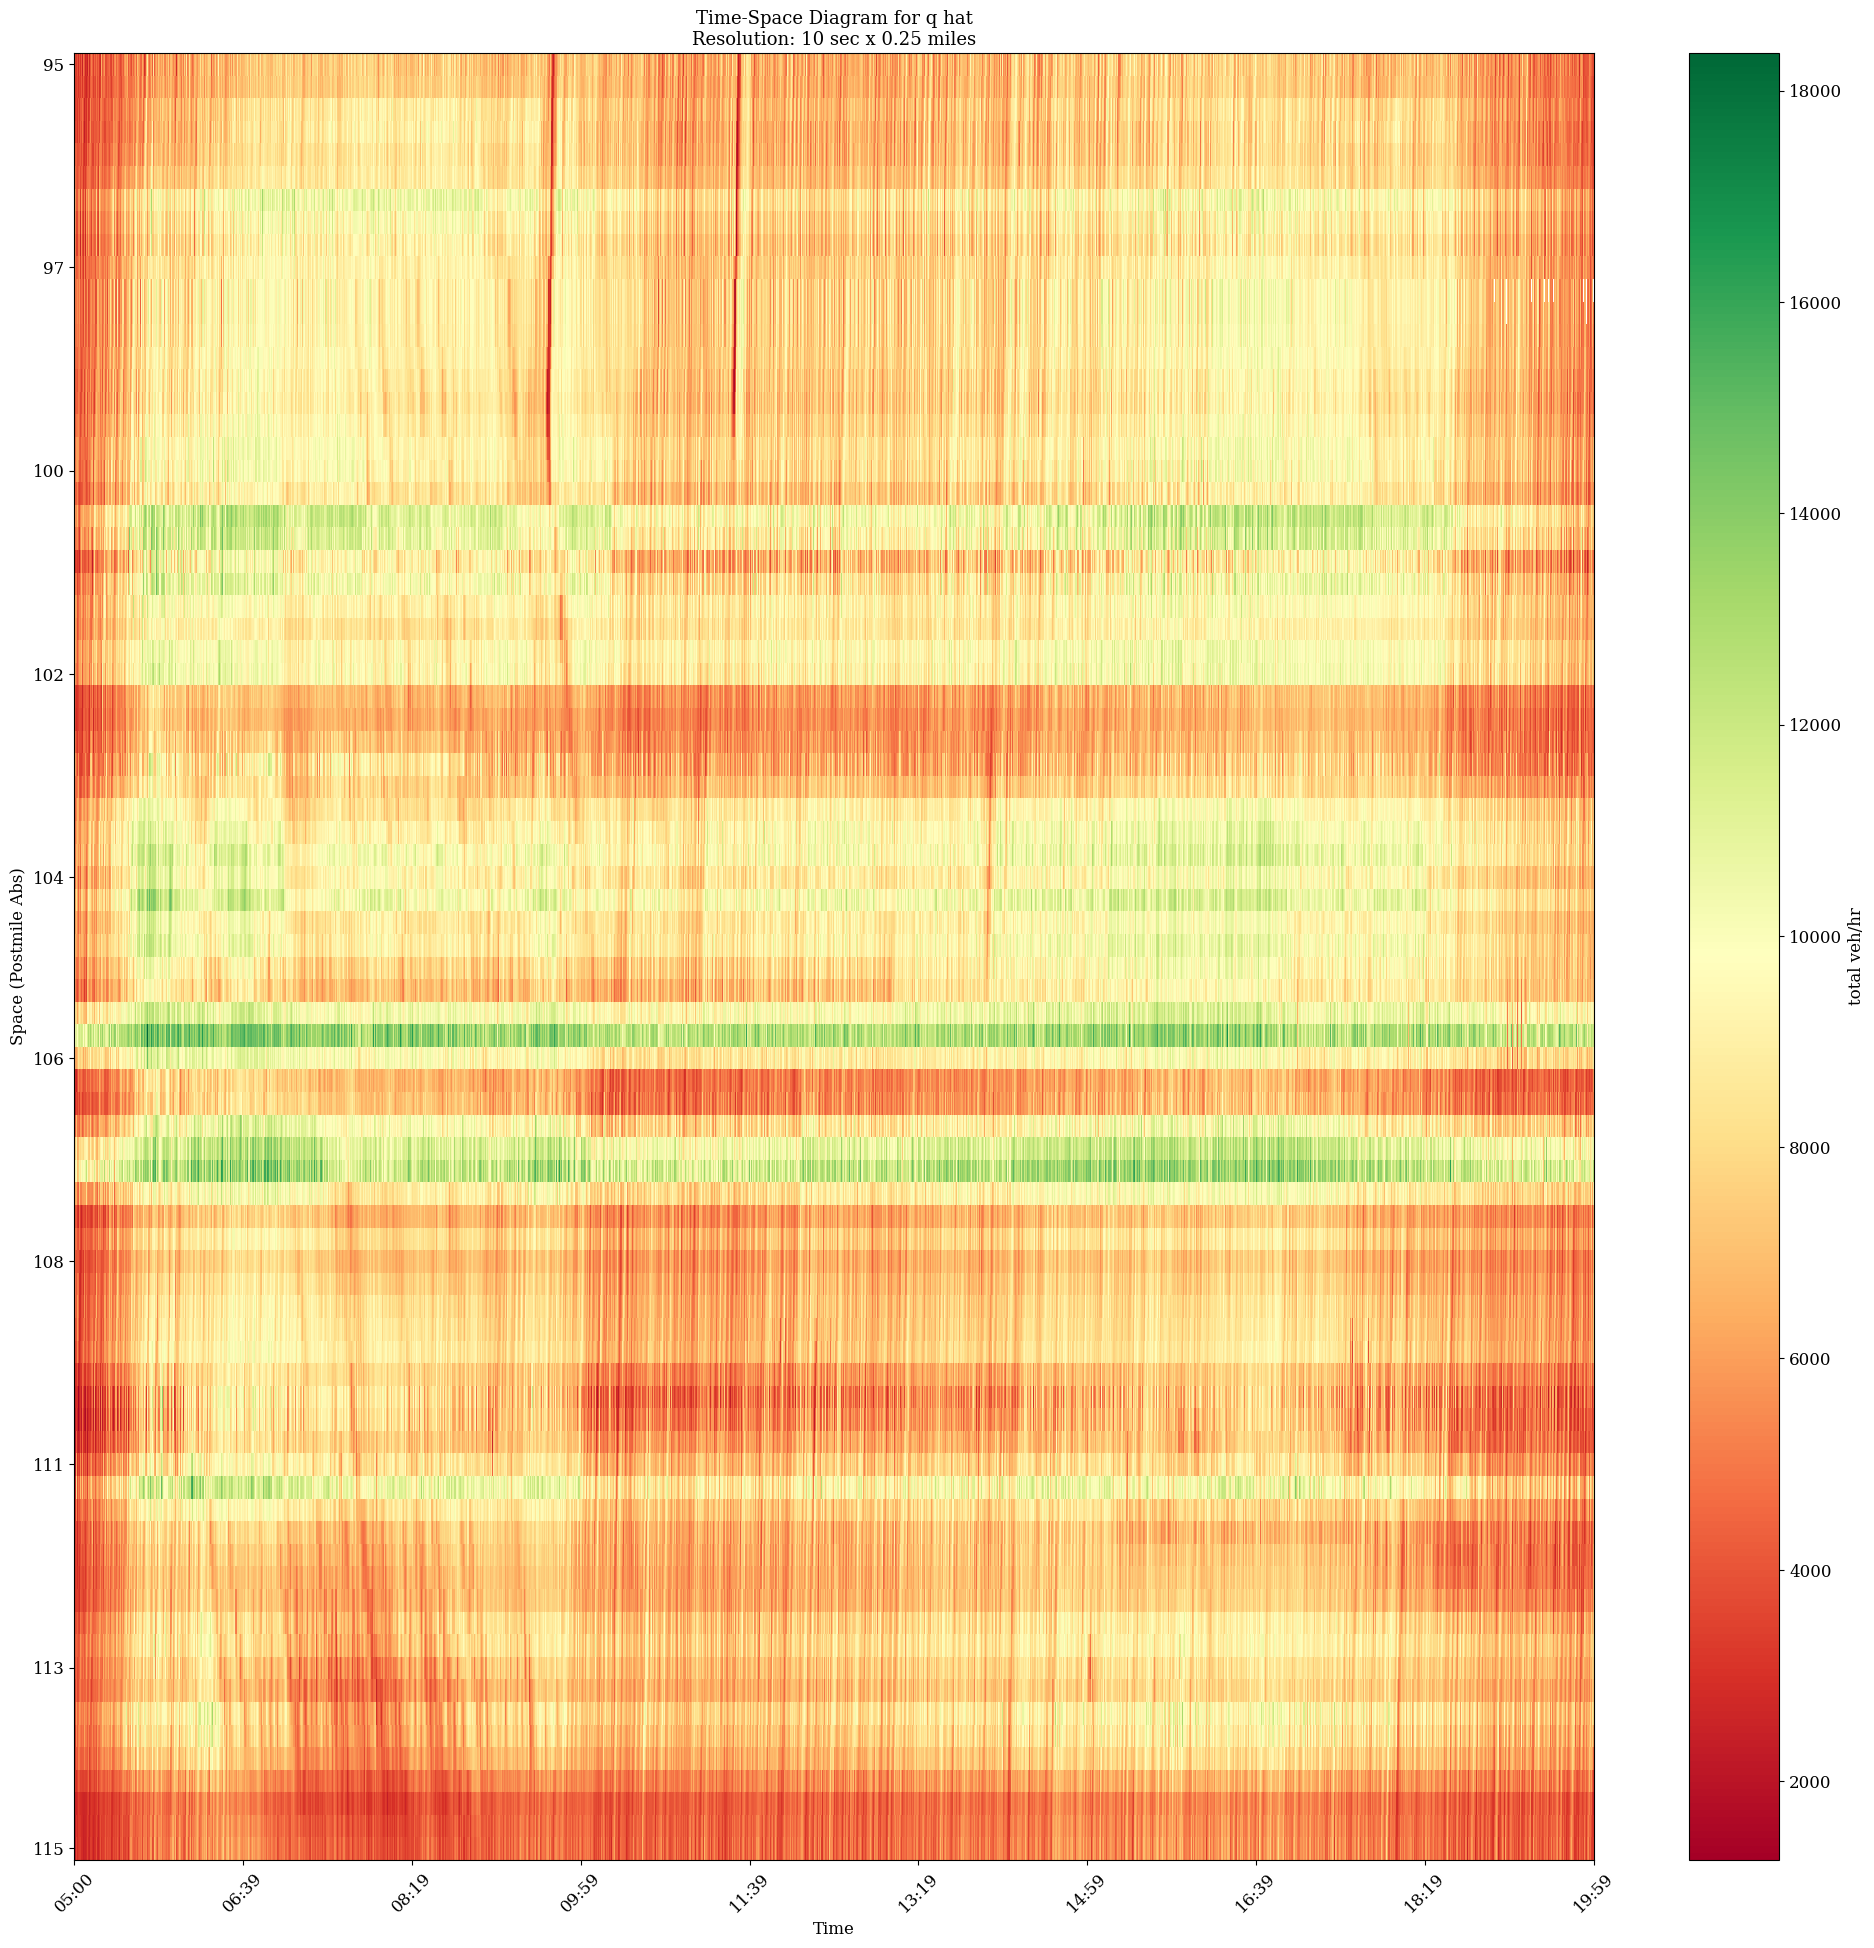

inferred time increment: 0 days 00:00:10
inferred space increment: -0.4 km
num time bins: 5397
num space bins: 80
num space edges: 80


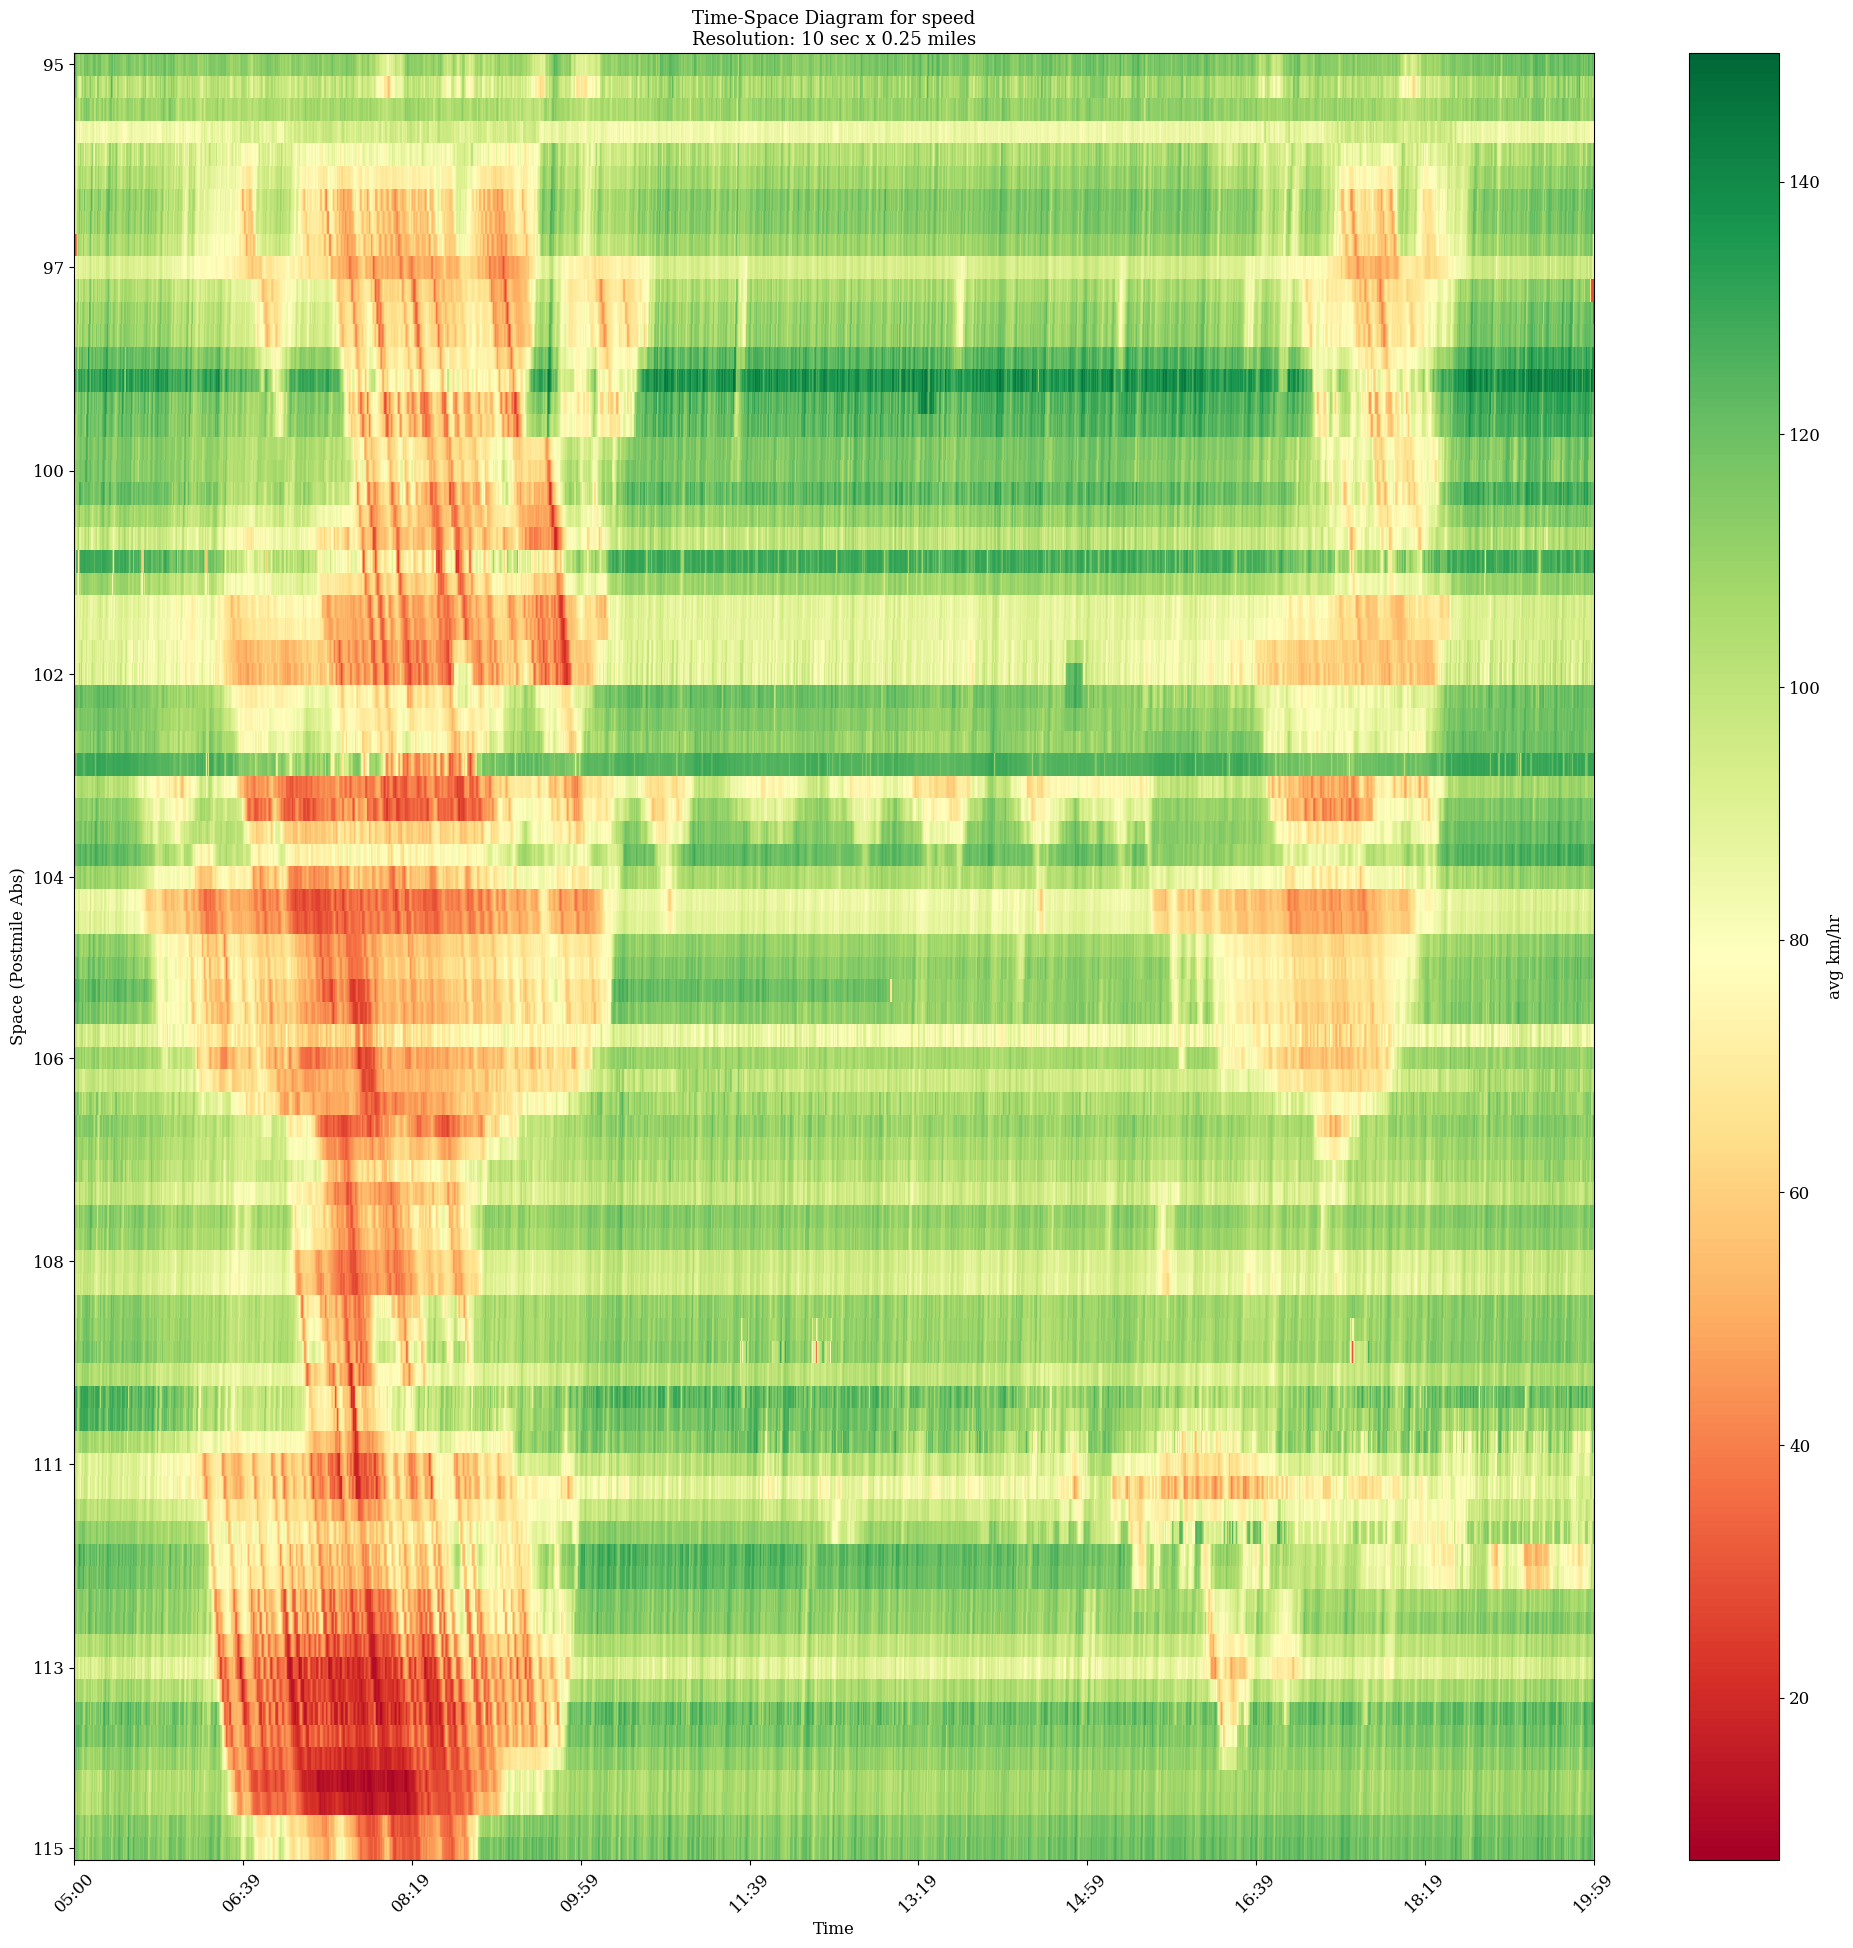

In [51]:
# Multiple the per-lane flows by the ground truth number of lanes
flow_matrix_total = flow_matrix_smoothed * lanes_per_bin[:, np.newaxis]

# Convert all entries in the speed matrix to kph
speed_matrix_kmh = speed_matrix * MILES_TO_KM

# flow_matrix_total = flow_matrix_total[:,:-120]
# speed_matrix_kmh = speed_matrix_kmh[:,:-120]

# Calibration code expects time on axis 0 and segment on axis 1.
q_hat = flow_matrix_total.T
v_hat = speed_matrix_kmh.T
rho_hat = q_hat / v_hat

np.save(array_dir / "q_hat.npy", q_hat)
np.save(array_dir / "v_hat.npy", v_hat)
np.save(array_dir / "rho_hat.npy", rho_hat)

# Sanity check before calibration
calibration_summary = pd.DataFrame({
    "matrix": ["q_hat", "v_hat", "rho_hat"],
    "shape": [str(q_hat.shape), str(v_hat.shape), str(rho_hat.shape)],
    "min": [np.nanmin(q_hat), np.nanmin(v_hat), np.nanmin(rho_hat)],
    "max": [np.nanmax(q_hat), np.nanmax(v_hat), np.nanmax(rho_hat)],
})
display(calibration_summary)

plot_matrix(rho_hat.T, "rho_hat", "total veh/km", t_min, t_max, start_pm, end_pm)
plot_matrix(q_hat.T, "q hat", "total veh/hr", t_min, t_max, start_pm, end_pm)
plot_matrix(v_hat.T, "speed", "avg km/hr", t_min, t_max, start_pm, end_pm)

# plot_matrix(rho_hat, "rho_hat transposed", "total veh/km", t_min, t_max, start_pm, end_pm)
# plot_matrix(q_hat, "q hat transposed", "total veh/hr", t_min, t_max, start_pm, end_pm)
# plot_matrix(v_hat, "speed transposed", "avg km/hr", t_min, t_max, start_pm, end_pm)